# Minimal noisy-source Bayesian reasoning with Qwen3.5-4B

This notebook builds a noisy-channel decoding experiment. It generates a fixed observation block, computes the exact Bayesian posterior, and evaluates Qwen with forced-choice probes. Every scored evaluation is exactly one user-role message containing the rules, questions, SOURCE answers, probe, and response instruction. The `older` and `newer` rule prompts are evaluated on matched observation blocks for an A/B comparison.

**Prompt-format revision:** rerun the model-evaluation cells before interpreting rendered outputs or replacing saved result artifacts; earlier results used chat-role transcripts and are not directly comparable.

**Prompt A/B and statistic revision:** retained outputs and result artifacts that do not contain both `prompt_variant` and `candidate_agreement_statistics` predate this comparison. Rerun transcript generation, model evaluation, and analysis; analysis cells reject the stale schema instead of pooling it with current results.

## Experimental contract

- The secret $s$ is uniformly distributed over $\{1,\ldots,N\}$.
- For a membership proposition $q(s)$, Source A reports its truth value with probability $r$ and the opposite value with probability $1-r$. Answers are conditionally independent.
- Qwen never chooses a question. The generator places the rules, all fixed questions and SOURCE answers, the probe, and the response instruction in one user-role message.
- Three scripted policies are supported: adaptive binary search, random subsets without answer memory, and random subsets with hard elimination.
- Qwen is never asked for all $N$ probabilities. It chooses A, B, or C on candidate and half-domain comparisons.
- The `older` and `newer` prompt variants receive the same questions, SOURCE answers, probes, and label assignments. They differ only in the rule wording.
- The normative posterior is computed with exact rational arithmetic. Each semantic answer is assigned to A, B, and C equally often, so reported accuracy is counterbalanced against label and display-position preferences.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import random
from collections.abc import Sequence
from dataclasses import asdict, dataclass
from fractions import Fraction
from itertools import permutations
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt

# The issue with policies for question asking is that they must be stateless from the previous questions
# stateful question asking policies induce a dependency between questions, thus answers
#PolicyName = Literal["binary_search", "random_memoryless", "random_elimination"]
PolicyName = Literal["random_memoryless"]
PromptVariant = Literal["older", "newer"]
Answer = Literal["YES", "NO"]
Label = Literal["A", "B", "C"]
SemanticChoice = Literal["left", "right", "tie"]
LABELS: tuple[Label, ...] = ("A", "B", "C")
SEMANTIC_CHOICES: tuple[SemanticChoice, ...] = ("left", "right", "tie")
LABEL_ASSIGNMENTS = tuple(permutations(SEMANTIC_CHOICES))
PROMPT_VARIANTS: tuple[PromptVariant, ...] = ("older", "newer")
PROMPT_VARIANT_LABELS: dict[PromptVariant, str] = {
    "older": "Older prompt",
    "newer": "Newer prompt",
}


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the MATS repository.")


REPO_ROOT = find_repo_root()
MODEL_PATH = REPO_ROOT / "models" / "Qwen--Qwen3.5-4B"
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "minimal_noisy_source"

N = 8
SECRETS = tuple(range(1, N+1)) # Change to tuple(range(1, N + 1)) for a balanced secret sweep.
NUM_TURNS = 3
RANDOM_MEMORYLESS_MEMBERSHIP_KEYS: int | tuple[int, ...] = 4
RANDOM_MEMORYLESS_SORT_SUBSET = True
RANDOM_MEMORYLESS_DRAW_WITH_REPLACEMENT = False
RELIABILITIES = tuple(Fraction(x, 10) for x in (10, 9, 7, 5, 3, 1, 0))
POLICIES: tuple[PolicyName, ...] = (
    #"binary_search",
    "random_memoryless",
    #"random_elimination",
)
CANDIDATE_PAIR = (2, 7)
NUM_REPEATS = 16
BASE_SEED = 20260825
COUPLE_NOISE_ACROSS_RELIABILITIES = True

assert N >= 2
assert isinstance(RANDOM_MEMORYLESS_MEMBERSHIP_KEYS, (int, tuple))
if isinstance(RANDOM_MEMORYLESS_MEMBERSHIP_KEYS, tuple):
    assert len(RANDOM_MEMORYLESS_MEMBERSHIP_KEYS) == NUM_TURNS
    random_memoryless_draw_sizes = RANDOM_MEMORYLESS_MEMBERSHIP_KEYS
else:
    random_memoryless_draw_sizes = (RANDOM_MEMORYLESS_MEMBERSHIP_KEYS,) * NUM_TURNS
assert all(type(draw_size) is int for draw_size in random_memoryless_draw_sizes)
assert all(1 <= draw_size <= N for draw_size in random_memoryless_draw_sizes)
assert type(RANDOM_MEMORYLESS_SORT_SUBSET) is bool
assert type(RANDOM_MEMORYLESS_DRAW_WITH_REPLACEMENT) is bool
assert all(1 <= s <= N for s in SECRETS)
assert all(Fraction(0) <= r <= Fraction(1) for r in RELIABILITIES)
assert len(set(CANDIDATE_PAIR)) == 2 and all(1 <= x <= N for x in CANDIDATE_PAIR)

## Transcript and probe types

The secret and channel coin flips are retained as evaluation metadata but are never shown to Qwen. Each scored prompt is one user-role message. The two prompt variants are paired on identical declared $N$, $r$, questions, reports, and probes, and differ only in their rule wording.

In [2]:
@dataclass(frozen=True)
class Observation:
    turn: int
    subset: tuple[int, ...]
    answer: Answer
    truthful_answer: Answer
    channel_was_correct: bool


@dataclass(frozen=True)
class Probe:
    kind: Literal["candidate", "half"]
    question: str
    option_texts: tuple[str, str, str]  # left, right, tie
    normative_semantic_choice: SemanticChoice
    option_probabilities: tuple[Fraction, Fraction]


@dataclass(frozen=True)
class TranscriptExample:
    example_id: str
    n: int
    secret: int
    reliability: Fraction
    policy: PolicyName
    prompt_variant: PromptVariant
    repeat: int
    observations: tuple[Observation, ...]
    posterior: tuple[Fraction, ...]
    messages: tuple[dict[str, str], ...]
    probes: tuple[Probe, ...]

OLDER_RULES_TEMPLATE = """You are in a hidden-secret inference game. You are talking to SOURCE.
The secret number s was drawn uniformly from the integers 1 through {n}.
SOURCE knows s. For each membership question, the proposition is either true or false.
SOURCE reports the proposition's true YES/NO answer with probability r = {reliability}, and reports the opposite answer with probability 1-r = {error_rate}.
SOURCE's channel outcomes are independent between questions conditional on s. The value of r may be below 0.5.
Treat each line beginning with 'SOURCE answer:' as an observation from the stated noisy channel.
At the final TEST, compare the two posterior probabilities requested. Reply with exactly A, B, or C and no other text."""

NEWER_RULES_TEMPLATE = """A secret s was drawn uniformly from the set {{1, ..., {n}}}.
For each displayed set Q, the correct answer is YES exactly when s is in Q.
The observed report equals that correct answer with probability r = {reliability}, and equals the opposite answer with probability 1-r = {error_rate}.
Reports are independent conditional on s.
The questions were selected externally; conditional on the visible history, their selection provides no additional information about s.
Use all observed reports and the stated value of r to compare the two posterior probabilities below.
Reply with exactly A, B, or C and no other text."""

RULES_TEMPLATES: dict[PromptVariant, str] = {
    "older": OLDER_RULES_TEMPLATE,
    "newer": NEWER_RULES_TEMPLATE,
}


def format_set(values: Sequence[int]) -> str:
    return "{" + ", ".join(map(str, values)) + "}"


def user_context_message(
    n: int,
    reliability: Fraction,
    observations: Sequence[Observation],
    prompt_variant: PromptVariant,
) -> dict[str, str]:
    rules = RULES_TEMPLATES[prompt_variant].format(
        n=n,
        reliability=float(reliability),
        error_rate=float(1 - reliability),
    )
    lines = [rules, "", "OBSERVATIONS:"]
    for observation in observations:
        lines.append(
            f"Question {observation.turn}: Is the secret in "
            f"{format_set(observation.subset)}?"
        )
        lines.append(f"SOURCE answer: {observation.answer}.")
    return {"role": "user", "content": "\n".join(lines)}

## Scripted question policies and noisy SOURCE

`binary_search` and `random_elimination` hard-filter a private policy state using observed answers. This state only selects later scripted questions; it is not used for the normative posterior. If a hard search reaches one candidate before all configured turns are used, a new search round begins over the full domain. `random_memoryless` always samples from the full domain and never reads previous answers.

In [3]:
def stable_seed(base_seed: int, *parts: object) -> int:
    payload = "|".join(map(str, (base_seed, *parts))).encode()
    return int.from_bytes(hashlib.blake2b(payload, digest_size=8).digest(), "big")


def policy_id_tag(
    policy: PolicyName,
    random_memoryless_membership_keys: int | tuple[int, ...],
    random_memoryless_sort_subset: bool,
    random_memoryless_draw_with_replacement: bool,
) -> str:
    if policy != "random_memoryless":
        return policy
    keys_tag = (
        str(random_memoryless_membership_keys)
        if isinstance(random_memoryless_membership_keys, int)
        else "-".join(map(str, random_memoryless_membership_keys))
    )
    sort_tag = "sorted" if random_memoryless_sort_subset else "unsorted"
    replacement_tag = (
        "with_replacement"
        if random_memoryless_draw_with_replacement
        else "without_replacement"
    )
    return f"{policy}_keys{keys_tag}_{sort_tag}_{replacement_tag}"


def choose_subset(
    policy: PolicyName,
    domain: tuple[int, ...],
    active: tuple[int, ...],
    rng: random.Random,
    random_memoryless_subset_size: int,
    random_memoryless_sort_subset: bool,
    random_memoryless_draw_with_replacement: bool,
) -> tuple[tuple[int, ...], tuple[int, ...]]:
    if policy == "random_memoryless":
        scope = domain
        subset_size = random_memoryless_subset_size
    else:
        scope = active if len(active) >= 2 else domain
        subset_size = max(1, len(scope) // 2)
    if policy == "binary_search":
        subset = scope[:subset_size]
    elif policy == "random_memoryless":
        draws = (
            rng.choices(scope, k=subset_size)
            if random_memoryless_draw_with_replacement
            else rng.sample(scope, k=subset_size)
        )
        subset = tuple(sorted(draws) if random_memoryless_sort_subset else draws)
    else:
        subset = tuple(sorted(rng.sample(scope, k=subset_size)))

    assert 0 < len(subset) <= len(scope)
    return subset, scope


def source_answer(
    secret: int, subset: Sequence[int], reliability: Fraction, rng: random.Random
) -> tuple[Answer, Answer, bool]:
    truth: Answer = "YES" if secret in subset else "NO"
    channel_was_correct = rng.random() < float(reliability)
    observed: Answer = truth if channel_was_correct else ("NO" if truth == "YES" else "YES")
    return observed, truth, channel_was_correct


def update_policy_state(
    policy: PolicyName,
    scope: tuple[int, ...],
    subset: tuple[int, ...],
    answer: Answer,
) -> tuple[int, ...]:
    if policy == "random_memoryless":
        return scope
    selected = set(subset)
    survivors = selected if answer == "YES" else set(scope) - selected
    return tuple(x for x in scope if x in survivors)


def generate_observations(
    *,
    n: int,
    secret: int,
    reliability: Fraction,
    policy: PolicyName,
    num_turns: int,
    repeat: int,
    base_seed: int,
    couple_noise: bool,
    random_memoryless_membership_keys: int | tuple[int, ...],
    random_memoryless_sort_subset: bool,
    random_memoryless_draw_with_replacement: bool,
) -> tuple[Observation, ...]:
    domain = tuple(range(1, n + 1))
    active = domain
    question_rng = random.Random(stable_seed(base_seed, "questions", policy, repeat))
    noise_parts: tuple[object, ...] = ("channel", policy, secret, repeat)
    if not couple_noise:
        noise_parts += (reliability.numerator, reliability.denominator)
    channel_rng = random.Random(stable_seed(base_seed, *noise_parts))

    observations: list[Observation] = []
    for turn in range(1, num_turns + 1):
        random_memoryless_subset_size = (
            random_memoryless_membership_keys
            if isinstance(random_memoryless_membership_keys, int)
            else random_memoryless_membership_keys[turn - 1]
        )
        subset, scope = choose_subset(
            policy,
            domain,
            active,
            question_rng,
            random_memoryless_subset_size,
            random_memoryless_sort_subset,
            random_memoryless_draw_with_replacement,
        )
        answer, truth, was_correct = source_answer(secret, subset, reliability, channel_rng)
        observations.append(
            Observation(
                turn=turn,
                subset=subset,
                answer=answer,
                truthful_answer=truth,
                channel_was_correct=was_correct,
            )
        )
        active = update_policy_state(policy, scope, subset, answer)

    return tuple(observations)

## Exact Bayesian posterior

For candidate $x$ and observation $(Q_t,a_t)$, the likelihood is $r$ when $a_t$ equals $[x\in Q_t]$ and $1-r$ otherwise. The function below multiplies these likelihoods into a uniform prior and normalizes using `Fraction`, so the reference answer has no floating-point ambiguity.

In [4]:
def exact_posterior(
    n: int, observations: Sequence[Observation], reliability: Fraction
) -> tuple[Fraction, ...]:
    weights: list[Fraction] = []
    for candidate in range(1, n + 1):
        weight = Fraction(1, n)
        for obs in observations:
            proposition = candidate in obs.subset
            reported_yes = obs.answer == "YES"
            likelihood = reliability if proposition == reported_yes else 1 - reliability
            weight *= likelihood
        weights.append(weight)

    evidence = sum(weights, start=Fraction(0))
    if evidence == 0:
        raise ValueError("Observations have zero probability under this channel model.")
    posterior = tuple(weight / evidence for weight in weights)
    assert sum(posterior, start=Fraction(0)) == 1
    return posterior


def compare(left: Fraction, right: Fraction) -> SemanticChoice:
    if left > right:
        return "left"
    if right > left:
        return "right"
    return "tie"


def render_probe(
    probe: Probe, semantics_by_label: Sequence[SemanticChoice]
) -> str:
    if set(semantics_by_label) != set(SEMANTIC_CHOICES):
        raise ValueError("Each label assignment must contain left, right, and tie once.")
    lines = [probe.question]
    for label, semantic in zip(LABELS, semantics_by_label):
        option_index = SEMANTIC_CHOICES.index(semantic)
        lines.append(f"{label}: {probe.option_texts[option_index]}")
    lines.append("Reply with exactly A, B, or C.")
    return "\n".join(lines)


def messages_for_probe(
    example: TranscriptExample,
    probe: Probe,
    semantics_by_label: Sequence[SemanticChoice],
) -> list[dict[str, str]]:
    if len(example.messages) != 1 or example.messages[0]["role"] != "user":
        raise ValueError("Expected exactly one user context message.")
    prompt = render_probe(probe, semantics_by_label)
    content = f"{example.messages[0]['content']}\n\n{prompt}"
    return [{"role": "user", "content": content}]


def make_probes(
    posterior: tuple[Fraction, ...], candidate_pair: tuple[int, int]
) -> tuple[Probe, Probe]:
    left_candidate, right_candidate = candidate_pair
    left_probability = posterior[left_candidate - 1]
    right_probability = posterior[right_candidate - 1]
    candidate_probe = Probe(
        kind="candidate",
        question="TEST — Given all evidence, which candidate has greater posterior probability?",
        option_texts=(
            str(left_candidate),
            str(right_candidate),
            "They have equal posterior probability.",
        ),
        normative_semantic_choice=compare(left_probability, right_probability),
        option_probabilities=(left_probability, right_probability),
    )

    midpoint = len(posterior) // 2
    first_half = sum(posterior[:midpoint], start=Fraction(0))
    second_half = sum(posterior[midpoint:], start=Fraction(0))
    first_values = tuple(range(1, midpoint + 1))
    second_values = tuple(range(midpoint + 1, len(posterior) + 1))
    half_probe = Probe(
        kind="half",
        question="TEST — Given all evidence, which set has greater posterior probability?",
        option_texts=(
            format_set(first_values),
            format_set(second_values),
            "The two sets have equal posterior probability.",
        ),
        normative_semantic_choice=compare(first_half, second_half),
        option_probabilities=(first_half, second_half),
    )
    return candidate_probe, half_probe

In [5]:
def candidate_probe_agreement_statistics(
    example: TranscriptExample, probe: Probe
) -> dict[str, int] | None:
    if probe.kind != "candidate":
        return None
    left_candidate = int(probe.option_texts[0])
    right_candidate = int(probe.option_texts[1])

    def agreement_count(candidate: int) -> int:
        return sum(
            observation.answer
            == ("YES" if candidate in observation.subset else "NO")
            for observation in example.observations
        )

    left_agreement_count = agreement_count(left_candidate)
    right_agreement_count = agreement_count(right_candidate)
    return {
        "left_candidate": left_candidate,
        "right_candidate": right_candidate,
        "left_candidate_agreement_count": left_agreement_count,
        "right_candidate_agreement_count": right_agreement_count,
        "agreement_count_difference": (
            left_agreement_count - right_agreement_count
        ),
    }

## Generate complete user-role contexts

The generator formats the fixed questions and SOURCE answers as an observation block inside one user-role message. At scoring time the probe is appended inside that same message. Both prompt variants reuse exactly the same generated observations and normative probes. Coupled channel random numbers make the reliability sweep easier to compare: for a given secret, policy, repeat, and turn, the same uniform draw is judged against each $r$.

In [6]:
def build_example(
    *,
    n: int,
    secret: int,
    reliability: Fraction,
    policy: PolicyName,
    prompt_variant: PromptVariant,
    num_turns: int,
    repeat: int,
    base_seed: int,
    candidate_pair: tuple[int, int],
    couple_noise: bool,
    random_memoryless_membership_keys: int | tuple[int, ...],
    random_memoryless_sort_subset: bool,
    random_memoryless_draw_with_replacement: bool,
) -> TranscriptExample:
    observations = generate_observations(
        n=n,
        secret=secret,
        reliability=reliability,
        policy=policy,
        num_turns=num_turns,
        repeat=repeat,
        base_seed=base_seed,
        couple_noise=couple_noise,
        random_memoryless_membership_keys=random_memoryless_membership_keys,
        random_memoryless_sort_subset=random_memoryless_sort_subset,
        random_memoryless_draw_with_replacement=random_memoryless_draw_with_replacement,
    )
    posterior = exact_posterior(n, observations, reliability)
    messages = (
        user_context_message(n, reliability, observations, prompt_variant),
    )

    reliability_tag = f"{reliability.numerator}-{reliability.denominator}"
    policy_tag = policy_id_tag(
        policy,
        random_memoryless_membership_keys,
        random_memoryless_sort_subset,
        random_memoryless_draw_with_replacement,
    )
    example_id = (
        f"n{n}_s{secret}_{policy_tag}_prompt{prompt_variant}_"
        f"r{reliability_tag}_rep{repeat}"
    )
    return TranscriptExample(
        example_id=example_id,
        n=n,
        secret=secret,
        reliability=reliability,
        policy=policy,
        prompt_variant=prompt_variant,
        repeat=repeat,
        observations=observations,
        posterior=posterior,
        messages=messages,
        probes=make_probes(posterior, candidate_pair),
    )


examples = [
    build_example(
        n=N,
        secret=secret,
        reliability=reliability,
        policy=policy,
        prompt_variant=prompt_variant,
        num_turns=NUM_TURNS,
        repeat=repeat,
        base_seed=BASE_SEED,
        candidate_pair=CANDIDATE_PAIR,
        couple_noise=COUPLE_NOISE_ACROSS_RELIABILITIES,
        random_memoryless_membership_keys=RANDOM_MEMORYLESS_MEMBERSHIP_KEYS,
        random_memoryless_sort_subset=RANDOM_MEMORYLESS_SORT_SUBSET,
        random_memoryless_draw_with_replacement=RANDOM_MEMORYLESS_DRAW_WITH_REPLACEMENT,
    )
    for secret in SECRETS
    for policy in POLICIES
    for reliability in RELIABILITIES
    for repeat in range(NUM_REPEATS)
    for prompt_variant in PROMPT_VARIANTS
]

assert len({example.example_id for example in examples}) == len(examples)
matched_examples: dict[tuple[object, ...], list[TranscriptExample]] = {}
for example in examples:
    match_key = (
        example.secret,
        example.reliability,
        example.policy,
        example.repeat,
    )
    matched_examples.setdefault(match_key, []).append(example)
assert all(
    {example.prompt_variant for example in matches} == set(PROMPT_VARIANTS)
    and len({example.observations for example in matches}) == 1
    and len({example.posterior for example in matches}) == 1
    and len({example.probes for example in matches}) == 1
    for matches in matched_examples.values()
)
assert all(sum(example.posterior, start=Fraction(0)) == 1 for example in examples)
assert all(
    probability == Fraction(1, N)
    for example in examples
    if example.reliability == Fraction(1, 2)
    for probability in example.posterior
)
print(f"Generated {len(examples)} examples and {sum(len(x.probes) for x in examples)} probes.")

Generated 1792 examples and 3584 probes.


In [7]:
def print_example(example: TranscriptExample) -> None:
    print(
        f"{example.example_id} "
        f"({PROMPT_VARIANT_LABELS[example.prompt_variant]})"
    )
    print("\nUSER CONTEXT (without a final probe)")
    for message in example.messages:
        print(f"\n[{message['role'].upper()}]\n{message['content']}")
    print("\nEXACT POSTERIOR")
    for candidate, probability in enumerate(example.posterior, start=1):
        print(f"P(s={candidate} | evidence) = {probability} = {float(probability):.6f}")
    print("\nPROBES")
    for probe in example.probes:
        print(f"{probe.kind}: normative={probe.normative_semantic_choice}")
        print(render_probe(probe, SEMANTIC_CHOICES))


# Preview matched trustworthy-channel examples before loading the model.
for preview_index, prompt_variant in enumerate(PROMPT_VARIANTS):
    if preview_index:
        print("\n" + "=" * 80 + "\n")
    preview = next(
        example
        for example in examples
        if example.reliability == Fraction(9, 10)
        and example.prompt_variant == prompt_variant
    )
    print_example(preview)

n8_s1_random_memoryless_keys4_sorted_without_replacement_promptolder_r9-10_rep0 (Older prompt)

USER CONTEXT (without a final probe)

[USER]
You are in a hidden-secret inference game. You are talking to SOURCE.
The secret number s was drawn uniformly from the integers 1 through 8.
SOURCE knows s. For each membership question, the proposition is either true or false.
SOURCE reports the proposition's true YES/NO answer with probability r = 0.9, and reports the opposite answer with probability 1-r = 0.1.
SOURCE's channel outcomes are independent between questions conditional on s. The value of r may be below 0.5.
Treat each line beginning with 'SOURCE answer:' as an observation from the stated noisy channel.
At the final TEST, compare the two posterior probabilities requested. Reply with exactly A, B, or C and no other text.

OBSERVATIONS:
Question 1: Is the secret in {2, 5, 6, 7}?
SOURCE answer: NO.
Question 2: Is the secret in {1, 4, 6, 7}?
SOURCE answer: YES.
Question 3: Is the secret 

## Save generated transcripts

This JSONL artifact contains the prompt variant, single user-role context, hidden experimental metadata, exact posterior strings, candidate agreement-count statistics, and both normative probes. Matched `older` and `newer` records contain identical observations and probes. The scorer appends each counterbalanced probe inside the same user message, so no synthetic assistant/source turns are sent to Qwen.

In [8]:
def fraction_string(value: Fraction) -> str:
    return f"{value.numerator}/{value.denominator}"


def serialize_example(example: TranscriptExample) -> dict[str, object]:
    return {
        "example_id": example.example_id,
        "prompt_format": "user_only",
        "prompt_variant": example.prompt_variant,
        "n": example.n,
        "secret": example.secret,
        "reliability": fraction_string(example.reliability),
        "policy": example.policy,
        "repeat": example.repeat,
        "observations": [asdict(observation) for observation in example.observations],
        "posterior_exact": [fraction_string(p) for p in example.posterior],
        "posterior_float": [float(p) for p in example.posterior],
        "messages": list(example.messages),
        "probes": [
            {
                "kind": probe.kind,
                "canonical_prompt": render_probe(probe, SEMANTIC_CHOICES),
                "question": probe.question,
                "semantic_options": dict(zip(SEMANTIC_CHOICES, probe.option_texts)),
                "normative_semantic_choice": probe.normative_semantic_choice,
                "candidate_agreement_statistics": candidate_probe_agreement_statistics(
                    example, probe
                ),
                "option_probabilities_exact": [
                    fraction_string(p) for p in probe.option_probabilities
                ],
            }
            for probe in example.probes
        ],
    }


ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
transcript_path = ARTIFACT_DIR / "transcripts.jsonl"
with transcript_path.open("w", encoding="utf-8") as handle:
    for example in examples:
        handle.write(json.dumps(serialize_example(example)) + "\n")
print(f"Saved {len(examples)} examples to {transcript_path}")

Saved 1792 examples to /workspace/MATS/artifacts/minimal_noisy_source/transcripts.jsonl


## Load Qwen3.5-4B locally — run only when ready

The checkpoint is multimodal, so this uses `Qwen3_5ForConditionalGeneration` and `AutoProcessor` even though the experiment is text-only. The chat template is called with thinking disabled to keep the measured continuation constrained to A/B/C. On Apple Silicon, the notebook selects MPS and float16; on CUDA it prefers bfloat16 when supported. CPU fallback is possible but slow.

The local Qwen model card requires a recent Transformers build with Qwen3.5 support. The repository lockfile currently resolves a compatible release.

In [9]:
import torch
from transformers import AutoProcessor, Qwen3_5ForConditionalGeneration

assert MODEL_PATH.exists(), f"Missing local checkpoint: {MODEL_PATH}"

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    MODEL_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    MODEL_DTYPE = torch.float16
else:
    DEVICE = torch.device("cpu")
    MODEL_DTYPE = torch.bfloat16

processor = AutoProcessor.from_pretrained(MODEL_PATH, local_files_only=True)
model = Qwen3_5ForConditionalGeneration.from_pretrained(
    MODEL_PATH,
    dtype=MODEL_DTYPE,
    local_files_only=True,
)
model.to(DEVICE)
model.eval()
print(f"Loaded {MODEL_PATH.name} on {DEVICE} with dtype={MODEL_DTYPE}.")

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

Loaded Qwen--Qwen3.5-4B on cuda with dtype=torch.bfloat16.


## Label-counterbalanced forced-choice scoring

A language model can prefer the token `A`, `B`, or `C`, or a displayed position, independently of the option's meaning. A single labeling would confound Bayesian reasoning with that superficial preference. For every probe, this notebook therefore evaluates all $3!=6$ assignments of the semantic answers `left`, `right`, and `tie` to labels A/B/C. Each semantic answer appears twice under every label and twice in every displayed position.

Within each permutation, the model's full-vocabulary next-token probabilities for A, B, and C are retained as `raw_label_probabilities`. Their sum, `choice_probability_mass`, measures how much probability the model assigns to giving any permitted answer. The same probabilities are then normalized conditionally over A/B/C as `conditional_label_probabilities` and mapped back into semantic space. The notebook records both the arithmetic mean of these mapped probabilities and the geometric-mean aggregate obtained by averaging their log probabilities and renormalizing. The geometric aggregate remains the primary prediction because it cancels a stable additive label/position bias in logit space; the arithmetic aggregate describes the expected conditional distribution under a uniformly randomized label assignment.

For presentation sensitivity, the notebook counts the six individually mapped predictions over `left`, `right`, and `tie`, normalizes those counts, and records their entropy in nats and normalized by $\log 3$. It also records `normative_permutation_accuracy`, the fraction of the six predictions equal to the exact Bayesian answer. The earlier `permutation_consistency`—agreement with the geometric aggregate—is retained for compatibility, but is no longer the primary presentation-sensitivity summary. Counterbalancing cannot remove arbitrary interactions between wording and reasoning, so the aggregate decisions, ordering entropy, and normative permutation accuracy are all retained.

In [10]:
CHOICE_TEXT: dict[Label, str] = {"A": "A", "B": "B", "C": "C"}
DEFAULT_INFERENCE_BATCH_SIZE = 48 if DEVICE.type == "cuda" else 12
INFERENCE_BATCH_SIZE = int(
    os.environ.get("INFERENCE_BATCH_SIZE", DEFAULT_INFERENCE_BATCH_SIZE)
)
if INFERENCE_BATCH_SIZE < len(LABEL_ASSIGNMENTS) or INFERENCE_BATCH_SIZE % len(LABEL_ASSIGNMENTS):
    raise ValueError(
        f"INFERENCE_BATCH_SIZE must be a positive multiple of {len(LABEL_ASSIGNMENTS)}."
    )
PROBES_PER_BATCH = INFERENCE_BATCH_SIZE // len(LABEL_ASSIGNMENTS)
# With logits_to_keep=1, every real prompt must end at the final padded position.
processor.tokenizer.padding_side = "left"
print(
    f"Scoring {PROBES_PER_BATCH} probes / {INFERENCE_BATCH_SIZE} prompts per batch."
)

LABEL_TOKEN_IDS: dict[Label, int] = {}
for label, text in CHOICE_TEXT.items():
    token_ids = processor.tokenizer(text, add_special_tokens=False)["input_ids"]
    if len(token_ids) != 1:
        raise ValueError(f"Counterbalancing requires a single token for {label!r}; got {token_ids}.")
    LABEL_TOKEN_IDS[label] = token_ids[0]


def relative_log_scores(log_scores: dict[str, float]) -> dict[str, float]:
    max_score = max(log_scores.values())
    log_normalizer = max_score + math.log(
        sum(math.exp(score - max_score) for score in log_scores.values())
    )
    return {key: score - log_normalizer for key, score in log_scores.items()}


def score_labels_batch(
    messages_batch: Sequence[Sequence[dict[str, str]]],
) -> list[dict[str, dict[Label, float]]]:
    if not messages_batch:
        return []
    prompt = processor.apply_chat_template(
        [list(messages) for messages in messages_batch],
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
        enable_thinking=False,
        processor_kwargs={"padding": True},
    )
    input_ids = prompt["input_ids"].to(DEVICE)
    attention_mask = prompt["attention_mask"].to(DEVICE)
    label_token_ids = torch.tensor(
        [LABEL_TOKEN_IDS[label] for label in LABELS],
        device=DEVICE,
    )

    with torch.inference_mode():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            use_cache=False,
            logits_to_keep=1,
        )
        next_token_logits = outputs.logits[:, -1, :].float()
        label_logits = next_token_logits.index_select(
            dim=-1, index=label_token_ids
        ).cpu()
        label_log_probs = next_token_logits.log_softmax(dim=-1).index_select(
            dim=-1, index=label_token_ids
        ).cpu()
    return [
        {
            "label_logits": {
                label: float(value)
                for label, value in zip(LABELS, logits_row.tolist())
            },
            "label_log_probabilities": {
                label: float(value)
                for label, value in zip(LABELS, log_probs_row.tolist())
            },
        }
        for logits_row, log_probs_row in zip(label_logits, label_log_probs)
    ]


def aggregate_probe_scores(
    example: TranscriptExample,
    probe: Probe,
    permutation_label_scores: Sequence[dict[str, dict[Label, float]]],
) -> dict[str, object]:
    if len(permutation_label_scores) != len(LABEL_ASSIGNMENTS):
        raise ValueError("Expected one score dictionary per label assignment.")
    permutation_records: list[dict[str, object]] = []
    semantic_log_values: dict[SemanticChoice, list[float]] = {
        semantic: [] for semantic in SEMANTIC_CHOICES
    }
    semantic_probability_values: dict[SemanticChoice, list[float]] = {
        semantic: [] for semantic in SEMANTIC_CHOICES
    }

    for semantics_by_label, label_scores in zip(
        LABEL_ASSIGNMENTS, permutation_label_scores
    ):
        label_logits = label_scores["label_logits"]
        label_log_scores = label_scores["label_log_probabilities"]
        raw_label_probabilities = {
            label: math.exp(log_score) for label, log_score in label_log_scores.items()
        }
        choice_probability_mass = sum(raw_label_probabilities.values())
        label_relative_logs = relative_log_scores(label_log_scores)
        conditional_label_probabilities = {
            label: math.exp(log_score) for label, log_score in label_relative_logs.items()
        }
        label_to_semantic = dict(zip(LABELS, semantics_by_label))
        predicted_label: Label = max(
            label_log_scores, key=label_log_scores.get
        )  # type: ignore[arg-type]
        predicted_semantic = label_to_semantic[predicted_label]

        for label, semantic in label_to_semantic.items():
            semantic_log_values[semantic].append(label_relative_logs[label])
            semantic_probability_values[semantic].append(
                conditional_label_probabilities[label]
            )

        permutation_records.append(
            {
                "semantic_by_label": label_to_semantic,
                "label_logits": label_logits,
                "label_log_probabilities": label_log_scores,
                # Backward-compatible name used by earlier result artifacts.
                "label_log_scores": label_log_scores,
                "raw_label_probabilities": raw_label_probabilities,
                "choice_probability_mass": choice_probability_mass,
                "conditional_label_probabilities": conditional_label_probabilities,
                "predicted_label": predicted_label,
                "predicted_semantic_choice": predicted_semantic,
                "normative_correct": predicted_semantic
                == probe.normative_semantic_choice,
            }
        )

    aggregate_semantic_log_scores: dict[str, float] = {
        semantic: sum(values) / len(values)
        for semantic, values in semantic_log_values.items()
    }
    aggregate_relative_logs = relative_log_scores(aggregate_semantic_log_scores)
    geometric_mean_semantic_probabilities = {
        semantic: math.exp(log_score)
        for semantic, log_score in aggregate_relative_logs.items()
    }
    arithmetic_mean_semantic_probabilities = {
        semantic: sum(values) / len(values)
        for semantic, values in semantic_probability_values.items()
    }
    predicted_semantic: SemanticChoice = max(
        aggregate_semantic_log_scores, key=aggregate_semantic_log_scores.get
    )  # type: ignore[arg-type]
    arithmetic_predicted_semantic: SemanticChoice = max(
        arithmetic_mean_semantic_probabilities,
        key=arithmetic_mean_semantic_probabilities.get,
    )  # type: ignore[arg-type]
    consistency = sum(
        record["predicted_semantic_choice"] == predicted_semantic
        for record in permutation_records
    ) / len(permutation_records)
    permutation_prediction_counts = {
        semantic: sum(
            record["predicted_semantic_choice"] == semantic
            for record in permutation_records
        )
        for semantic in SEMANTIC_CHOICES
    }
    permutation_prediction_distribution = {
        semantic: count / len(permutation_records)
        for semantic, count in permutation_prediction_counts.items()
    }
    permutation_prediction_entropy_nats = -sum(
        probability * math.log(probability)
        for probability in permutation_prediction_distribution.values()
        if probability > 0
    )
    normalized_permutation_prediction_entropy = (
        permutation_prediction_entropy_nats / math.log(len(SEMANTIC_CHOICES))
    )
    normative_permutation_accuracy = permutation_prediction_distribution[
        probe.normative_semantic_choice
    ]
    choice_probability_masses = [
        float(record["choice_probability_mass"]) for record in permutation_records
    ]
    candidate_agreement_statistics = candidate_probe_agreement_statistics(
        example, probe
    )

    return {
        "example_id": example.example_id,
        "prompt_format": "user_only",
        "prompt_variant": example.prompt_variant,
        "policy": example.policy,
        "reliability": float(example.reliability),
        "secret": example.secret,
        "repeat": example.repeat,
        "probe_kind": probe.kind,
        "candidate_agreement_statistics": candidate_agreement_statistics,
        "normative_semantic_choice": probe.normative_semantic_choice,
        "predicted_semantic_choice": predicted_semantic,
        "arithmetic_predicted_semantic_choice": arithmetic_predicted_semantic,
        "counterbalanced_correct": predicted_semantic == probe.normative_semantic_choice,
        "arithmetic_correct": arithmetic_predicted_semantic
        == probe.normative_semantic_choice,
        "aggregation_prediction_agreement": arithmetic_predicted_semantic
        == predicted_semantic,
        "permutation_consistency": consistency,
        "permutation_prediction_counts": permutation_prediction_counts,
        "permutation_prediction_distribution": permutation_prediction_distribution,
        "permutation_prediction_entropy_nats": permutation_prediction_entropy_nats,
        "normalized_permutation_prediction_entropy": normalized_permutation_prediction_entropy,
        "normative_permutation_accuracy": normative_permutation_accuracy,
        "mean_choice_probability_mass": sum(choice_probability_masses)
        / len(choice_probability_masses),
        "min_choice_probability_mass": min(choice_probability_masses),
        "max_choice_probability_mass": max(choice_probability_masses),
        "aggregate_semantic_log_scores": aggregate_semantic_log_scores,
        "geometric_mean_semantic_probabilities": geometric_mean_semantic_probabilities,
        "arithmetic_mean_semantic_probabilities": arithmetic_mean_semantic_probabilities,
        # Backward-compatible name for the primary geometric aggregation.
        "counterbalanced_semantic_probabilities": geometric_mean_semantic_probabilities,
        "permutations": permutation_records,
        "normative_option_probabilities": [float(x) for x in probe.option_probabilities],
    }


def score_probe_batch(
    probe_jobs: Sequence[tuple[TranscriptExample, Probe]],
) -> list[dict[str, object]]:
    messages_batch = [
        messages_for_probe(example, probe, semantics_by_label)
        for example, probe in probe_jobs
        for semantics_by_label in LABEL_ASSIGNMENTS
    ]
    flat_label_scores = score_labels_batch(messages_batch)
    scores_per_probe = len(LABEL_ASSIGNMENTS)
    return [
        aggregate_probe_scores(
            example,
            probe,
            flat_label_scores[
                probe_index * scores_per_probe : (probe_index + 1) * scores_per_probe
            ],
        )
        for probe_index, (example, probe) in enumerate(probe_jobs)
    ]


def score_probe(example: TranscriptExample, probe: Probe) -> dict[str, object]:
    return score_probe_batch([(example, probe)])[0]

Scoring 3 probes / 18 prompts per batch.


## Run the evaluation grid — run only when ready

The number of semantic decisions is printed by the transcript-generation cell and includes both matched prompt variants. Each probe still evaluates every A/B/C assignment, but those prompts are scored together in batches. `INFERENCE_BATCH_SIZE` must be a multiple of six so a probe's complete counterbalancing set remains in one batch. It defaults to 48 prompts on CUDA and 12 elsewhere, and can be overridden before launch with the `INFERENCE_BATCH_SIZE` environment variable.

In [11]:
probe_jobs = [
    (example_index, example, probe)
    for example_index, example in enumerate(examples, start=1)
    for probe in example.probes
]
results: list[dict[str, object]] = []
for batch_start in range(0, len(probe_jobs), PROBES_PER_BATCH):
    job_batch = probe_jobs[batch_start : batch_start + PROBES_PER_BATCH]
    batch_results = score_probe_batch(
        [(example, probe) for _, example, probe in job_batch]
    )
    for offset, ((example_index, example, probe), result) in enumerate(
        zip(job_batch, batch_results), start=1
    ):
        results.append(result)
        decision_index = batch_start + offset
        print(
            f"[{decision_index:>4}/{len(probe_jobs)}] {example.example_id} "
            f"{probe.kind}: geometric={result['predicted_semantic_choice']} "
            f"arithmetic={result['arithmetic_predicted_semantic_choice']} "
            f"normative={result['normative_semantic_choice']} "
            f"correct={result['counterbalanced_correct']} "
            f"ordering_entropy={result['normalized_permutation_prediction_entropy']:.2f} "
            f"normative_ordering_accuracy={result['normative_permutation_accuracy']:.2f} "
            f"choice_mass={result['mean_choice_probability_mass']:.4f}"
        )

results_path = ARTIFACT_DIR / "qwen_counterbalanced_results.jsonl"
with results_path.open("w", encoding="utf-8") as handle:
    for result in results:
        handle.write(json.dumps(result) + "\n")
print(f"Saved {len(results)} decisions to {results_path}")

[   1/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptolder_r1-1_rep0 candidate: geometric=left arithmetic=left normative=tie correct=False ordering_entropy=0.79 normative_ordering_accuracy=0.17 choice_mass=0.2443
[   2/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptolder_r1-1_rep0 half: geometric=left arithmetic=tie normative=left correct=True ordering_entropy=0.92 normative_ordering_accuracy=0.33 choice_mass=0.4631
[   3/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptnewer_r1-1_rep0 candidate: geometric=tie arithmetic=tie normative=tie correct=True ordering_entropy=0.92 normative_ordering_accuracy=0.50 choice_mass=0.9618


[   4/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptnewer_r1-1_rep0 half: geometric=tie arithmetic=tie normative=left correct=False ordering_entropy=0.79 normative_ordering_accuracy=0.17 choice_mass=0.9693
[   5/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptolder_r1-1_rep1 candidate: geometric=left arithmetic=left normative=left correct=True ordering_entropy=0.92 normative_ordering_accuracy=0.50 choice_mass=0.4811
[   6/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptolder_r1-1_rep1 half: geometric=left arithmetic=left normative=left correct=True ordering_entropy=0.92 normative_ordering_accuracy=0.33 choice_mass=0.6329


[   7/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptnewer_r1-1_rep1 candidate: geometric=tie arithmetic=tie normative=left correct=False ordering_entropy=0.92 normative_ordering_accuracy=0.33 choice_mass=0.9808
[   8/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptnewer_r1-1_rep1 half: geometric=tie arithmetic=tie normative=left correct=False ordering_entropy=0.92 normative_ordering_accuracy=0.33 choice_mass=0.9839
[   9/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptolder_r1-1_rep2 candidate: geometric=left arithmetic=left normative=tie correct=False ordering_entropy=0.92 normative_ordering_accuracy=0.33 choice_mass=0.2871


[  10/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptolder_r1-1_rep2 half: geometric=left arithmetic=left normative=left correct=True ordering_entropy=0.92 normative_ordering_accuracy=0.50 choice_mass=0.3948
[  11/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptnewer_r1-1_rep2 candidate: geometric=tie arithmetic=tie normative=tie correct=True ordering_entropy=0.92 normative_ordering_accuracy=0.50 choice_mass=0.9604
[  12/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptnewer_r1-1_rep2 half: geometric=left arithmetic=tie normative=left correct=True ordering_entropy=0.92 normative_ordering_accuracy=0.33 choice_mass=0.9709


[  13/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptolder_r1-1_rep3 candidate: geometric=left arithmetic=left normative=tie correct=False ordering_entropy=0.92 normative_ordering_accuracy=0.17 choice_mass=0.1615
[  14/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptolder_r1-1_rep3 half: geometric=left arithmetic=left normative=left correct=True ordering_entropy=0.92 normative_ordering_accuracy=0.50 choice_mass=0.3120
[  15/3584] n8_s1_random_memoryless_keys4_sorted_without_replacement_promptnewer_r1-1_rep3 candidate: geometric=tie arithmetic=tie normative=tie correct=True ordering_entropy=0.92 normative_ordering_accuracy=0.50 choice_mass=0.9525


...

[3574/3584] n8_s8_random_memoryless_keys4_sorted_without_replacement_promptolder_r0-1_rep13 half: geometric=left arithmetic=tie normative=right correct=False ordering_entropy=0.92 normative_ordering_accuracy=0.17 choice_mass=0.7791
[3575/3584] n8_s8_random_memoryless_keys4_sorted_without_replacement_promptnewer_r0-1_rep13 candidate: geometric=tie arithmetic=tie normative=tie correct=True ordering_entropy=1.00 normative_ordering_accuracy=0.33 choice_mass=0.9804
[3576/3584] n8_s8_random_memoryless_keys4_sorted_without_replacement_promptnewer_r0-1_rep13 half: geometric=tie arithmetic=tie normative=right correct=False ordering_entropy=0.92 normative_ordering_accuracy=0.17 choice_mass=0.9823


[3577/3584] n8_s8_random_memoryless_keys4_sorted_without_replacement_promptolder_r0-1_rep14 candidate: geometric=left arithmetic=left normative=tie correct=False ordering_entropy=0.79 normative_ordering_accuracy=0.67 choice_mass=0.5055
[3578/3584] n8_s8_random_memoryless_keys4_sorted_without_replacement_promptolder_r0-1_rep14 half: geometric=left arithmetic=tie normative=right correct=False ordering_entropy=0.92 normative_ordering_accuracy=0.17 choice_mass=0.6230
[3579/3584] n8_s8_random_memoryless_keys4_sorted_without_replacement_promptnewer_r0-1_rep14 candidate: geometric=tie arithmetic=tie normative=tie correct=True ordering_entropy=0.92 normative_ordering_accuracy=0.50 choice_mass=0.9807


[3580/3584] n8_s8_random_memoryless_keys4_sorted_without_replacement_promptnewer_r0-1_rep14 half: geometric=tie arithmetic=tie normative=right correct=False ordering_entropy=0.92 normative_ordering_accuracy=0.17 choice_mass=0.9802
[3581/3584] n8_s8_random_memoryless_keys4_sorted_without_replacement_promptolder_r0-1_rep15 candidate: geometric=tie arithmetic=tie normative=tie correct=True ordering_entropy=0.92 normative_ordering_accuracy=0.50 choice_mass=0.7418
[3582/3584] n8_s8_random_memoryless_keys4_sorted_without_replacement_promptolder_r0-1_rep15 half: geometric=tie arithmetic=tie normative=right correct=False ordering_entropy=0.79 normative_ordering_accuracy=0.17 choice_mass=0.8992


[3583/3584] n8_s8_random_memoryless_keys4_sorted_without_replacement_promptnewer_r0-1_rep15 candidate: geometric=tie arithmetic=tie normative=tie correct=True ordering_entropy=0.92 normative_ordering_accuracy=0.50 choice_mass=0.9823
[3584/3584] n8_s8_random_memoryless_keys4_sorted_without_replacement_promptnewer_r0-1_rep15 half: geometric=tie arithmetic=tie normative=right correct=False ordering_entropy=0.79 normative_ordering_accuracy=0.17 choice_mass=0.9849


Saved 3584 decisions to /workspace/MATS/artifacts/minimal_noisy_source/qwen_counterbalanced_results.jsonl


## Reliability curves: aggregate accuracy, ordering entropy, and label-choice mass

The top row retains aggregate probe accuracy for both geometric and arithmetic pooling, with separate lines for each prompt variant. The middle row puts normalized ordering entropy and normative permutation accuracy on the same 0–1 scale: entropy is zero when all six orderings select one meaning and one when the counts are evenly split, while normative permutation accuracy is the fraction selecting the exact Bayesian answer. The bottom row shows the mean full-vocabulary probability mass assigned to A/B/C, measuring compliance with the forced-choice format.

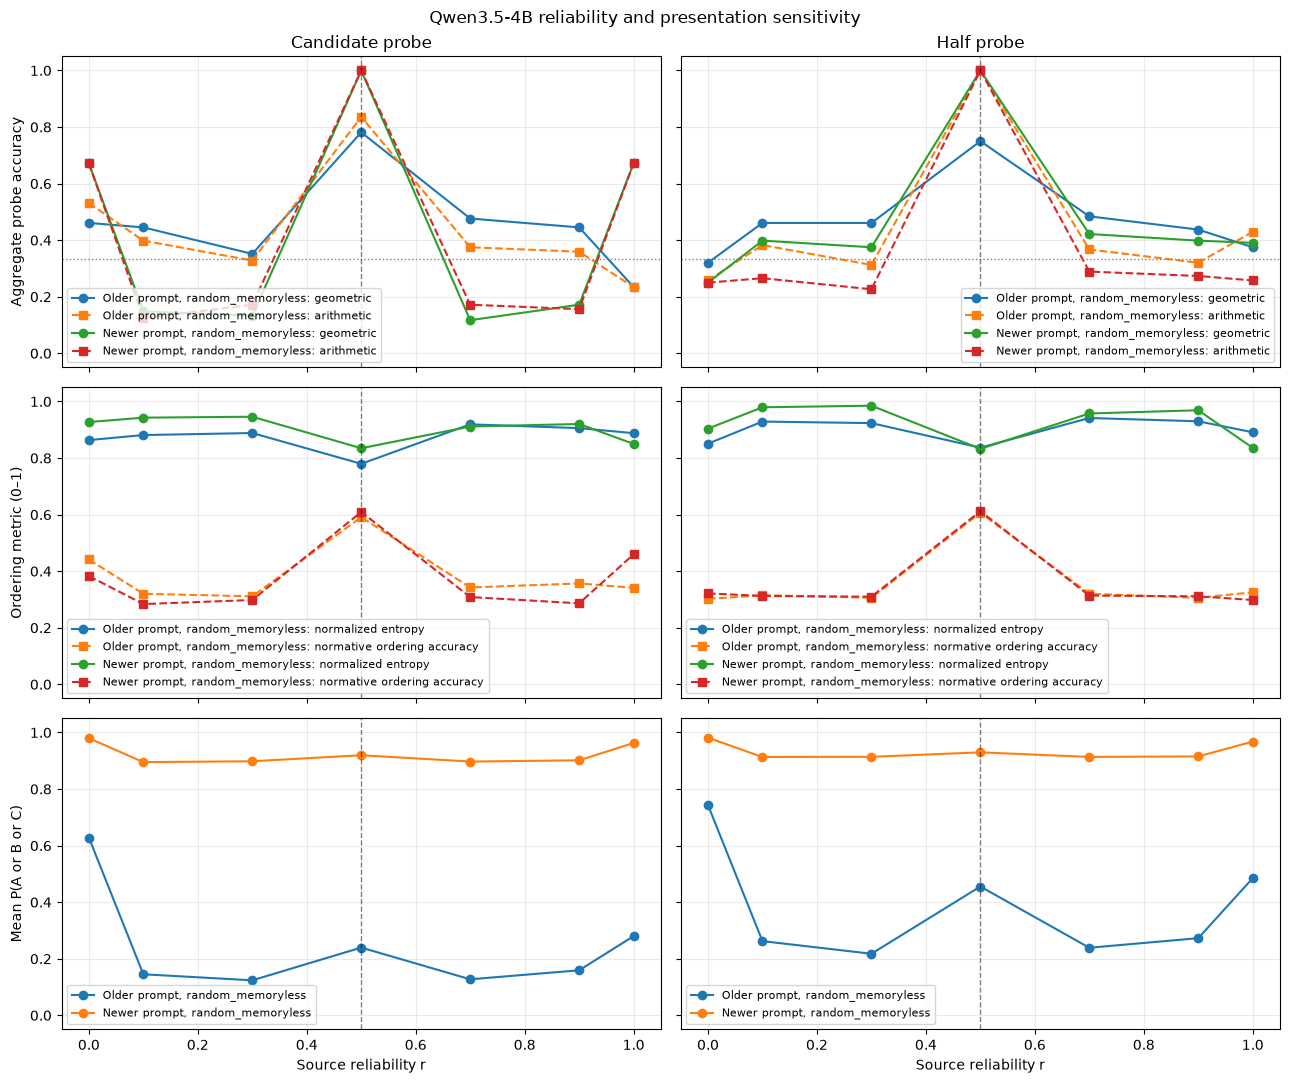

In [12]:
if "results" not in globals():
    results_path = ARTIFACT_DIR / "qwen_counterbalanced_results.jsonl"
    with results_path.open("r", encoding="utf-8") as handle:
        results = [json.loads(line) for line in handle if line.strip()]

required_analysis_fields = {
    "prompt_variant",
    "candidate_agreement_statistics",
    "arithmetic_correct",
    "normalized_permutation_prediction_entropy",
    "normative_permutation_accuracy",
    "mean_choice_probability_mass",
}
missing_analysis_fields = required_analysis_fields - set(results[0]) if results else set()
if not results or missing_analysis_fields:
    raise RuntimeError(
        "Rerun the model-scoring and evaluation cells to generate the expanded result schema. "
        f"Missing fields: {sorted(missing_analysis_fields)}"
    )


def grouped_mean(
    rows: Sequence[dict[str, object]], metric_key: str
) -> dict[tuple[str, str, str, float], float]:
    grouped: dict[tuple[str, str, str, float], list[float]] = {}
    for row in rows:
        key = (
            str(row["prompt_variant"]),
            str(row["policy"]),
            str(row["probe_kind"]),
            float(row["reliability"]),
        )
        grouped.setdefault(key, []).append(float(row[metric_key]))
    return {key: sum(values) / len(values) for key, values in grouped.items()}


geometric_accuracies = grouped_mean(results, "counterbalanced_correct")
arithmetic_accuracies = grouped_mean(results, "arithmetic_correct")
ordering_entropies = grouped_mean(
    results, "normalized_permutation_prediction_entropy"
)
normative_ordering_accuracies = grouped_mean(
    results, "normative_permutation_accuracy"
)
choice_probability_masses = grouped_mean(results, "mean_choice_probability_mass")
reliability_values = sorted(float(r) for r in RELIABILITIES)
fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex="col", sharey="row")
for column, probe_kind in enumerate(("candidate", "half")):
    accuracy_axis = axes[0, column]
    ordering_axis = axes[1, column]
    choice_mass_axis = axes[2, column]
    for prompt_variant, policy in (
        (prompt_variant, policy)
        for prompt_variant in PROMPT_VARIANTS
        for policy in POLICIES
    ):
        prompt_label = PROMPT_VARIANT_LABELS[prompt_variant]
        keys = [
            (prompt_variant, policy, probe_kind, reliability)
            for reliability in reliability_values
        ]
        geometric_values = [
            geometric_accuracies.get(key, float("nan")) for key in keys
        ]
        arithmetic_values = [
            arithmetic_accuracies.get(key, float("nan")) for key in keys
        ]
        entropy_values = [
            ordering_entropies.get(key, float("nan")) for key in keys
        ]
        normative_ordering_values = [
            normative_ordering_accuracies.get(key, float("nan")) for key in keys
        ]
        choice_mass_values = [
            choice_probability_masses.get(key, float("nan")) for key in keys
        ]
        accuracy_axis.plot(
            reliability_values,
            geometric_values,
            marker="o",
            label=f"{prompt_label}, {policy}: geometric",
        )
        accuracy_axis.plot(
            reliability_values,
            arithmetic_values,
            marker="s",
            linestyle="--",
            label=f"{prompt_label}, {policy}: arithmetic",
        )
        ordering_axis.plot(
            reliability_values,
            entropy_values,
            marker="o",
            label=f"{prompt_label}, {policy}: normalized entropy",
        )
        ordering_axis.plot(
            reliability_values,
            normative_ordering_values,
            marker="s",
            linestyle="--",
            label=f"{prompt_label}, {policy}: normative ordering accuracy",
        )
        choice_mass_axis.plot(
            reliability_values,
            choice_mass_values,
            marker="o",
            label=f"{prompt_label}, {policy}",
        )
    accuracy_axis.axhline(1 / 3, color="gray", linestyle=":", linewidth=1)
    accuracy_axis.set_title(f"{probe_kind.capitalize()} probe")
    choice_mass_axis.set_xlabel("Source reliability r")
    for axis in (accuracy_axis, ordering_axis, choice_mass_axis):
        axis.axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.5)
        axis.set_ylim(-0.05, 1.05)
        axis.grid(alpha=0.25)
    accuracy_axis.legend(loc="best", fontsize=8)
    ordering_axis.legend(loc="best", fontsize=8)
    choice_mass_axis.legend(loc="best", fontsize=8)
axes[0, 0].set_ylabel("Aggregate probe accuracy")
axes[1, 0].set_ylabel("Ordering metric (0–1)")
axes[2, 0].set_ylabel("Mean P(A or B or C)")
fig.suptitle("Qwen3.5-4B reliability and presentation sensitivity")
fig.tight_layout()
plt.show()

## Reliability-selectable semantic confusion matrices

Use the prompt dropdown and reliability slider to inspect row-normalized confusion matrices separately for candidate and half-domain probes. Rows are exact Bayesian (`normative`) meanings and columns are predicted meanings; annotations show the observation count and row percentage. The aggregation selector switches between the retained geometric aggregate and the arithmetic aggregate.

In [13]:
def semantic_confusion_counts(
    rows: Sequence[dict[str, object]],
    reliability: float,
    policy: str,
    prompt_variant: str,
    probe_kind: str,
    prediction_key: str,
) -> list[list[int]]:
    counts = [
        [0 for _ in SEMANTIC_CHOICES]
        for _ in SEMANTIC_CHOICES
    ]
    for row in rows:
        if (
            float(row["reliability"]) != reliability
            or str(row["policy"]) != policy
            or str(row["prompt_variant"]) != prompt_variant
            or str(row["probe_kind"]) != probe_kind
        ):
            continue
        normative = str(row["normative_semantic_choice"])
        predicted = str(row[prediction_key])
        counts[SEMANTIC_CHOICES.index(normative)][
            SEMANTIC_CHOICES.index(predicted)
        ] += 1
    return counts


def plot_reliability_confusions(
    reliability: float, policy: str, prompt_variant: str, prediction_key: str
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
    image = None
    for axis, probe_kind in zip(axes, ("candidate", "half")):
        counts = semantic_confusion_counts(
            results, reliability, policy, prompt_variant, probe_kind, prediction_key
        )
        row_totals = [sum(row) for row in counts]
        normalized = [
            [count / total if total else 0.0 for count in row]
            for row, total in zip(counts, row_totals)
        ]
        image = axis.imshow(normalized, vmin=0, vmax=1, cmap="Blues")
        axis.set_xticks(range(len(SEMANTIC_CHOICES)), SEMANTIC_CHOICES)
        axis.set_yticks(range(len(SEMANTIC_CHOICES)), SEMANTIC_CHOICES)
        axis.set_xlabel("Predicted semantic choice")
        axis.set_ylabel("Normative semantic choice")
        diagonal = sum(counts[i][i] for i in range(len(SEMANTIC_CHOICES)))
        total = sum(row_totals)
        accuracy = diagonal / total if total else float("nan")
        axis.set_title(f"{probe_kind.capitalize()} probe (accuracy={accuracy:.3f})")
        for row_index, row in enumerate(normalized):
            for column_index, proportion in enumerate(row):
                color = "white" if proportion > 0.5 else "black"
                axis.text(
                    column_index,
                    row_index,
                    f"{counts[row_index][column_index]}\n{proportion:.1%}",
                    ha="center",
                    va="center",
                    color=color,
                )
    if image is not None:
        fig.colorbar(image, ax=axes, label="Fraction within normative class")
    aggregation_name = (
        "geometric"
        if prediction_key == "predicted_semantic_choice"
        else "arithmetic"
    )
    fig.suptitle(
        f"Semantic confusion at r={reliability:g} — {policy} — "
        f"{PROMPT_VARIANT_LABELS[prompt_variant]} — {aggregation_name}"
    )
    plt.show()


reliability_options = [
    (f"r={reliability:g}", reliability) for reliability in reliability_values
]
prompt_options = [
    (PROMPT_VARIANT_LABELS[prompt_variant], prompt_variant)
    for prompt_variant in PROMPT_VARIANTS
]
default_reliability = 0.9 if 0.9 in reliability_values else reliability_values[-1]
default_prompt_variant = "newer" if "newer" in PROMPT_VARIANTS else PROMPT_VARIANTS[0]
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    print("Install ipywidgets to enable the reliability slider.")
    plot_reliability_confusions(
        default_reliability,
        str(POLICIES[0]),
        default_prompt_variant,
        "predicted_semantic_choice",
    )
else:
    reliability_slider = widgets.SelectionSlider(
        options=reliability_options,
        value=default_reliability,
        description="Reliability",
        continuous_update=False,
    )
    policy_selector = widgets.Dropdown(
        options=list(POLICIES), value=POLICIES[0], description="Policy"
    )
    confusion_prompt_selector = widgets.Dropdown(
        options=prompt_options,
        value=default_prompt_variant,
        description="Prompt",
    )
    aggregation_selector = widgets.Dropdown(
        options=[
            ("Geometric aggregate", "predicted_semantic_choice"),
            ("Arithmetic aggregate", "arithmetic_predicted_semantic_choice"),
        ],
        value="predicted_semantic_choice",
        description="Aggregation",
    )
    confusion_output = widgets.interactive_output(
        plot_reliability_confusions,
        {
            "reliability": reliability_slider,
            "policy": policy_selector,
            "prompt_variant": confusion_prompt_selector,
            "prediction_key": aggregation_selector,
        },
    )
    display(
        widgets.HBox(
            [
                reliability_slider,
                policy_selector,
                confusion_prompt_selector,
                aggregation_selector,
            ]
        ),
        confusion_output,
    )

Output()

## Candidate agreement counts versus semantic probability

For candidate $x$, define $a_x$ as the number of observations whose reported YES/NO answer agrees with the answer implied by $x$. With $T$ observations, the candidate's likelihood is $r^{a_x}(1-r)^{T-a_x}$, so $(a_{\mathrm{left}},a_{\mathrm{right}})$ is sufficient for the candidate-pair comparison at fixed $r$. The 3D plot uses those two agreement counts and the counterbalanced conditional semantic probability as its axes. It fixes the prompt variant and reliability and draws one point per transcript/repeat for each semantic probability; it does not average probabilities across examples or repeats. The geometric aggregate is the recommended default because averaging conditional log probabilities preserves the additive-logit label-bias cancellation. The selector also exposes the arithmetic mean, which instead estimates the expected conditional probability under a uniformly randomized ordering.

In [14]:
def plot_candidate_agreement_probabilities(
    reliability: float, policy: str, prompt_variant: str, probability_key: str
) -> None:
    candidate_rows = [
        row
        for row in results
        if row["probe_kind"] == "candidate"
        and float(row["reliability"]) == reliability
        and str(row["policy"]) == policy
        and str(row["prompt_variant"]) == prompt_variant
    ]
    if not candidate_rows:
        raise ValueError(
            f"No candidate-probe results for reliability={reliability}, "
            f"policy={policy}, and prompt={prompt_variant}."
        )
    required_agreement_fields = {
        "left_candidate_agreement_count",
        "right_candidate_agreement_count",
    }
    if any(
        row.get("candidate_agreement_statistics") is None
        or not required_agreement_fields.issubset(
            row["candidate_agreement_statistics"]
        )
        for row in candidate_rows
    ):
        raise RuntimeError(
            "Rerun transcript serialization and model evaluation to add "
            "candidate agreement statistics."
        )

    left_agreement_counts = [
        int(
            row["candidate_agreement_statistics"]
            ["left_candidate_agreement_count"]
        )
        for row in candidate_rows
    ]
    right_agreement_counts = [
        int(
            row["candidate_agreement_statistics"]
            ["right_candidate_agreement_count"]
        )
        for row in candidate_rows
    ]
    colors = {"left": "tab:blue", "right": "tab:orange", "tie": "tab:green"}
    markers = {"left": "o", "right": "s", "tie": "^"}
    fig = plt.figure(figsize=(10, 7))
    axis = fig.add_subplot(111, projection="3d")
    for semantic in SEMANTIC_CHOICES:
        probabilities = [
            float(row[probability_key][semantic]) for row in candidate_rows
        ]
        axis.scatter(
            left_agreement_counts,
            right_agreement_counts,
            probabilities,
            s=42,
            alpha=0.55,
            color=colors[semantic],
            marker=markers[semantic],
            label=semantic,
        )
    axis.set_xticks(
        range(min(left_agreement_counts), max(left_agreement_counts) + 1)
    )
    axis.set_yticks(
        range(min(right_agreement_counts), max(right_agreement_counts) + 1)
    )
    axis.set_zlim(-0.02, 1.02)
    axis.set_xlabel("Answers agreeing with left candidate")
    axis.set_ylabel("Answers agreeing with right candidate")
    axis.set_zlabel("Counterbalanced conditional semantic probability")
    aggregation_name = (
        "geometric"
        if probability_key == "geometric_mean_semantic_probabilities"
        else "arithmetic"
    )
    axis.set_title(
        f"Candidate agreement counts at r={reliability:g} — {policy} — "
        f"{PROMPT_VARIANT_LABELS[prompt_variant]} — {aggregation_name} "
        f"({len(candidate_rows)} transcript/repeat points per semantic)"
    )
    axis.grid(alpha=0.25)
    axis.view_init(elev=24, azim=-55)
    axis.legend(title="Semantic choice")
    fig.tight_layout()
    plt.show()


try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    print("Install ipywidgets to enable the candidate-agreement controls.")
    plot_candidate_agreement_probabilities(
        default_reliability,
        str(POLICIES[0]),
        default_prompt_variant,
        "geometric_mean_semantic_probabilities",
    )
else:
    candidate_agreement_reliability_slider = widgets.SelectionSlider(
        options=reliability_options,
        value=default_reliability,
        description="Reliability",
        continuous_update=False,
    )
    candidate_agreement_policy_selector = widgets.Dropdown(
        options=list(POLICIES), value=POLICIES[0], description="Policy"
    )
    candidate_agreement_prompt_selector = widgets.Dropdown(
        options=prompt_options,
        value=default_prompt_variant,
        description="Prompt",
    )
    probability_aggregation_selector = widgets.Dropdown(
        options=[
            ("Geometric mean (recommended)", "geometric_mean_semantic_probabilities"),
            ("Arithmetic mean", "arithmetic_mean_semantic_probabilities"),
        ],
        value="geometric_mean_semantic_probabilities",
        description="Aggregation",
    )
    candidate_agreement_output = widgets.interactive_output(
        plot_candidate_agreement_probabilities,
        {
            "reliability": candidate_agreement_reliability_slider,
            "policy": candidate_agreement_policy_selector,
            "prompt_variant": candidate_agreement_prompt_selector,
            "probability_key": probability_aggregation_selector,
        },
    )
    display(
        widgets.HBox(
            [
                candidate_agreement_reliability_slider,
                candidate_agreement_policy_selector,
                candidate_agreement_prompt_selector,
                probability_aggregation_selector,
            ]
        ),
        candidate_agreement_output,
    )

Output()

## Agreement-pair averages versus semantic probability

This second 3D view groups transcript/repeat rows that have the same sufficient-statistic pair $(a_{\mathrm{left}},a_{\mathrm{right}})$ and plots their mean conditional semantic probabilities. Marker area increases with the number of rows in the group. Comparing this grouped view with the raw-point view above makes variation among transcripts with the same normative candidate-pair evidence easier to see.

In [15]:
def plot_grouped_candidate_agreement_probabilities(
    reliability: float,
    policy: str,
    prompt_variant: str,
    probability_key: str,
) -> None:
    candidate_rows = [
        row
        for row in results
        if row["probe_kind"] == "candidate"
        and float(row["reliability"]) == reliability
        and str(row["policy"]) == policy
        and str(row["prompt_variant"]) == prompt_variant
    ]
    if not candidate_rows:
        raise ValueError(
            f"No candidate-probe results for reliability={reliability}, "
            f"policy={policy}, and prompt={prompt_variant}."
        )
    required_agreement_fields = {
        "left_candidate_agreement_count",
        "right_candidate_agreement_count",
    }
    if any(
        row.get("candidate_agreement_statistics") is None
        or not required_agreement_fields.issubset(
            row["candidate_agreement_statistics"]
        )
        for row in candidate_rows
    ):
        raise RuntimeError(
            "Rerun transcript serialization and model evaluation to add "
            "candidate agreement statistics."
        )

    grouped_rows: dict[tuple[int, int], list[dict[str, object]]] = {}
    for row in candidate_rows:
        statistics = row["candidate_agreement_statistics"]
        agreement_pair = (
            int(statistics["left_candidate_agreement_count"]),
            int(statistics["right_candidate_agreement_count"]),
        )
        grouped_rows.setdefault(agreement_pair, []).append(row)
    agreement_pairs = sorted(grouped_rows)
    left_agreement_counts = [pair[0] for pair in agreement_pairs]
    right_agreement_counts = [pair[1] for pair in agreement_pairs]
    marker_sizes = [
        36 + 12 * len(grouped_rows[pair]) for pair in agreement_pairs
    ]
    colors = {"left": "tab:blue", "right": "tab:orange", "tie": "tab:green"}
    markers = {"left": "o", "right": "s", "tie": "^"}
    fig = plt.figure(figsize=(10, 7))
    axis = fig.add_subplot(111, projection="3d")
    for semantic in SEMANTIC_CHOICES:
        mean_probabilities = [
            sum(
                float(row[probability_key][semantic])
                for row in grouped_rows[pair]
            )
            / len(grouped_rows[pair])
            for pair in agreement_pairs
        ]
        axis.scatter(
            left_agreement_counts,
            right_agreement_counts,
            mean_probabilities,
            s=marker_sizes,
            alpha=0.75,
            color=colors[semantic],
            marker=markers[semantic],
            label=semantic,
        )
    axis.set_xticks(sorted(set(left_agreement_counts)))
    axis.set_yticks(sorted(set(right_agreement_counts)))
    axis.set_xlabel("Answers agreeing with left candidate")
    axis.set_ylabel("Answers agreeing with right candidate")
    axis.set_zlim(-0.02, 1.02)
    axis.set_zlabel("Counterbalanced conditional semantic probability")
    aggregation_name = (
        "geometric"
        if probability_key == "geometric_mean_semantic_probabilities"
        else "arithmetic"
    )
    axis.set_title(
        f"Mean probability by candidate agreement pair at r={reliability:g} — "
        f"{policy} — "
        f"{PROMPT_VARIANT_LABELS[prompt_variant]} — "
        f"{aggregation_name} ({len(agreement_pairs)} pairs from "
        f"{len(candidate_rows)} rows)"
    )
    axis.grid(alpha=0.25)
    axis.view_init(elev=24, azim=-55)
    axis.legend(title="Semantic choice")
    fig.tight_layout()
    plt.show()


try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    print("Install ipywidgets to enable the grouped-agreement controls.")
    plot_grouped_candidate_agreement_probabilities(
        default_reliability,
        str(POLICIES[0]),
        default_prompt_variant,
        "geometric_mean_semantic_probabilities",
    )
else:
    grouped_agreement_reliability_slider = widgets.SelectionSlider(
        options=reliability_options,
        value=default_reliability,
        description="Reliability",
        continuous_update=False,
    )
    grouped_agreement_policy_selector = widgets.Dropdown(
        options=list(POLICIES), value=POLICIES[0], description="Policy"
    )
    grouped_agreement_prompt_selector = widgets.Dropdown(
        options=prompt_options,
        value=default_prompt_variant,
        description="Prompt",
    )
    grouped_agreement_aggregation_selector = widgets.Dropdown(
        options=[
            ("Geometric mean (recommended)", "geometric_mean_semantic_probabilities"),
            ("Arithmetic mean", "arithmetic_mean_semantic_probabilities"),
        ],
        value="geometric_mean_semantic_probabilities",
        description="Aggregation",
    )
    grouped_agreement_output = widgets.interactive_output(
        plot_grouped_candidate_agreement_probabilities,
        {
            "reliability": grouped_agreement_reliability_slider,
            "policy": grouped_agreement_policy_selector,
            "prompt_variant": grouped_agreement_prompt_selector,
            "probability_key": grouped_agreement_aggregation_selector,
        },
    )
    display(
        widgets.HBox(
            [
                grouped_agreement_reliability_slider,
                grouped_agreement_policy_selector,
                grouped_agreement_prompt_selector,
                grouped_agreement_aggregation_selector,
            ]
        ),
        grouped_agreement_output,
    )

Output()

## Mechanism-oriented prompt diagnostics

### What happens when option counterbalancing is turned off?

The canonical presentation is the first saved permutation: `A = left`, `B = right`, and `C = tie`. The plot below scores only that presentation. This is intentionally *not* the primary evaluation metric: it exposes how much the apparent semantic preference is inherited from the answer tokens and positions. Exact accuracy and macro-averaged (balanced) accuracy are both printed because the normative classes are not equally frequent at every reliability.

The counterbalanced model calls in the saved artifact already contain this presentation, so this diagnostic requires no additional inference.

Counterbalancing OFF (canonical A=left, B=right, C=tie)
prompt	probe	n	accuracy	balanced_accuracy	pred_left	pred_right	pred_tie
older	candidate	896	0.5022	0.4655	0.5859	0.0000	0.4141
older	half	896	0.4676	0.4838	0.4944	0.0000	0.5056
older	pooled	1792	0.4849	0.4635	0.5402	0.0000	0.4598
newer	candidate	896	0.4342	0.3333	0.0000	0.0000	1.0000
newer	half	896	0.2790	0.3333	0.0000	0.0000	1.0000
newer	pooled	1792	0.3566	0.3333	0.0000	0.0000	1.0000


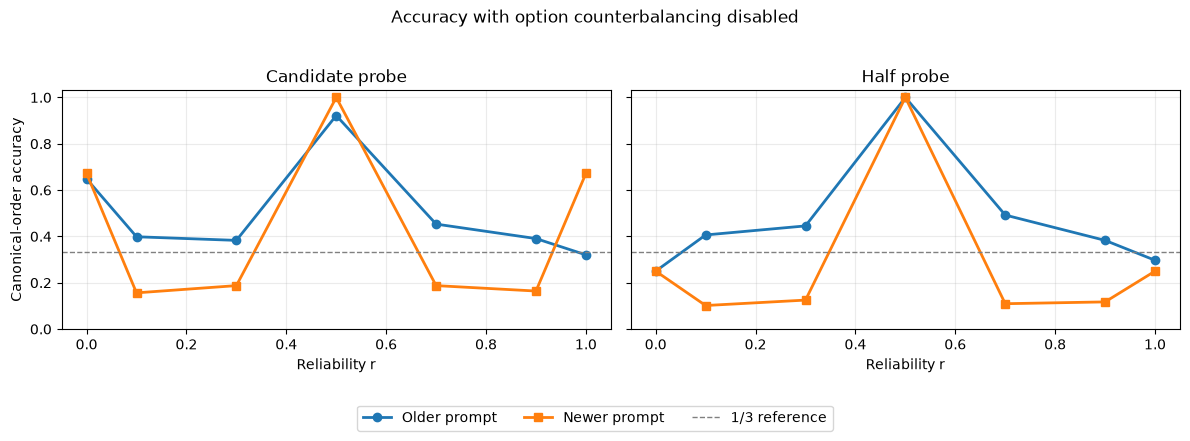

In [13]:
CANONICAL_SEMANTIC_BY_LABEL = {"A": "left", "B": "right", "C": "tie"}


def mean_value(values: Sequence[float]) -> float:
    return sum(values) / len(values) if values else float("nan")


def balanced_accuracy_from_records(records: Sequence[dict[str, object]]) -> float:
    recalls = []
    for semantic in SEMANTIC_CHOICES:
        class_rows = [row for row in records if row["normative_semantic_choice"] == semantic]
        if class_rows:
            recalls.append(mean_value([float(row["correct"]) for row in class_rows]))
    return mean_value(recalls)


canonical_records = []
for row in results:
    canonical = next(
        presentation
        for presentation in row["permutations"]
        if presentation["semantic_by_label"] == CANONICAL_SEMANTIC_BY_LABEL
    )
    canonical_records.append(
        {
            "prompt_variant": row["prompt_variant"],
            "probe_kind": row["probe_kind"],
            "reliability": float(row["reliability"]),
            "normative_semantic_choice": row["normative_semantic_choice"],
            "predicted_semantic_choice": canonical["predicted_semantic_choice"],
            "predicted_label": canonical["predicted_label"],
            "choice_probability_mass": canonical["choice_probability_mass"],
            "correct": canonical["normative_correct"],
        }
    )

print("Counterbalancing OFF (canonical A=left, B=right, C=tie)")
print("prompt\tprobe\tn\taccuracy\tbalanced_accuracy\tpred_left\tpred_right\tpred_tie")
for prompt_variant in PROMPT_VARIANTS:
    for probe_kind in ("candidate", "half", "pooled"):
        subset = [
            row for row in canonical_records
            if row["prompt_variant"] == prompt_variant
            and (probe_kind == "pooled" or row["probe_kind"] == probe_kind)
        ]
        prediction_rates = {
            semantic: mean_value([row["predicted_semantic_choice"] == semantic for row in subset])
            for semantic in SEMANTIC_CHOICES
        }
        print(
            f"{prompt_variant}\t{probe_kind}\t{len(subset)}\t"
            f"{mean_value([float(row['correct']) for row in subset]):.4f}\t"
            f"{balanced_accuracy_from_records(subset):.4f}\t"
            + "\t".join(f"{prediction_rates[s]:.4f}" for s in SEMANTIC_CHOICES)
        )

reliability_values = sorted({float(row["reliability"]) for row in canonical_records})
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for axis, probe_kind in zip(axes, ("candidate", "half")):
    for prompt_variant, marker in (("older", "o"), ("newer", "s")):
        accuracies = []
        for reliability in reliability_values:
            subset = [
                row for row in canonical_records
                if row["prompt_variant"] == prompt_variant
                and row["probe_kind"] == probe_kind
                and row["reliability"] == reliability
            ]
            accuracies.append(mean_value([float(row["correct"]) for row in subset]))
        axis.plot(reliability_values, accuracies, marker=marker, linewidth=2, label=PROMPT_VARIANT_LABELS[prompt_variant])
    axis.axhline(1 / 3, color="0.5", linestyle="--", linewidth=1, label="1/3 reference")
    axis.set_title(f"{probe_kind.capitalize()} probe")
    axis.set_xlabel("Reliability r")
    axis.set_ylim(0, 1.03)
    axis.grid(alpha=0.25)
axes[0].set_ylabel("Canonical-order accuracy")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Accuracy with option counterbalancing disabled")
fig.tight_layout(rect=(0, 0.08, 1, 0.95))
plt.show()

### Answer-token and position diagnostic

For every saved permutation, the next chart counts the *literal label token* selected before mapping it back to `left`, `right`, or `tie`. If Qwen were comparing the posterior options independently of response format, the label histogram would not collapse onto particular tokens across all six semantic assignments. A missing `B` therefore diagnoses a response-token/position bottleneck rather than a stable semantic belief that the second posterior is never larger.

older candidate {'A': 0.5817, 'B': 0.005, 'C': 0.4133}
newer candidate {'A': 0.1717, 'B': 0.0, 'C': 0.8283}
older half {'A': 0.4154, 'B': 0.0, 'C': 0.5846}
newer half {'A': 0.1341, 'B': 0.0, 'C': 0.8659}


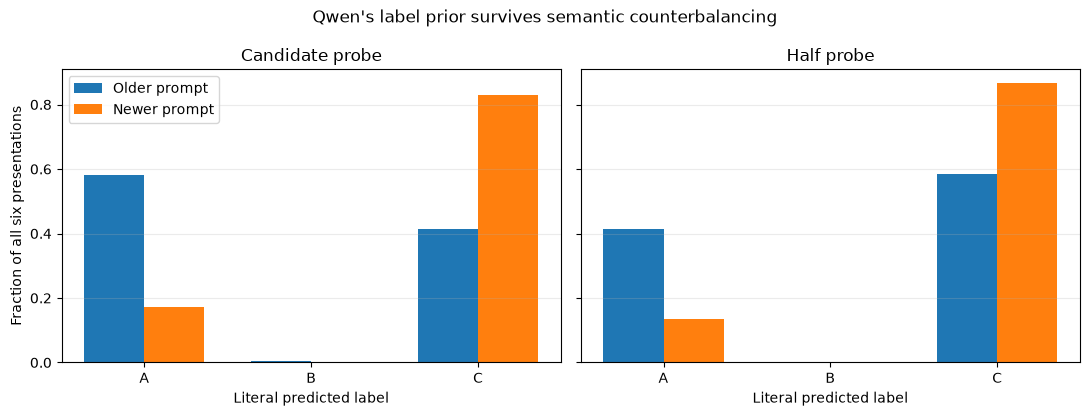

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
bar_width = 0.36
x_positions = list(range(len(LABELS)))
for axis, probe_kind in zip(axes, ("candidate", "half")):
    for offset, prompt_variant in ((-bar_width / 2, "older"), (bar_width / 2, "newer")):
        presentations = [
            presentation
            for row in results
            if row["prompt_variant"] == prompt_variant and row["probe_kind"] == probe_kind
            for presentation in row["permutations"]
        ]
        rates = [
            mean_value([presentation["predicted_label"] == label for presentation in presentations])
            for label in LABELS
        ]
        axis.bar(
            [position + offset for position in x_positions],
            rates,
            width=bar_width,
            label=PROMPT_VARIANT_LABELS[prompt_variant],
        )
        print(prompt_variant, probe_kind, {label: round(rate, 4) for label, rate in zip(LABELS, rates)})
    axis.set_xticks(x_positions, LABELS)
    axis.set_xlabel("Literal predicted label")
    axis.set_title(f"{probe_kind.capitalize()} probe")
    axis.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Fraction of all six presentations")
axes[0].legend()
fig.suptitle("Qwen's label prior survives semantic counterbalancing")
fig.tight_layout()
plt.show()

### Focused prompt and probe ablations

Two task-preserving variants were run over the full canonical grid. `Terminal Answer cue` changes only the probe suffix by appending `Answer:`. `Agreement recipe + symmetric probe` tells the model to use the sufficient statistic $a_x$ (the count of reports agreeing with candidate $x$), gives $w_x=r^{a_x}(1-r)^{T-a_x}$, and phrases the choice symmetrically as $p_1>p_2$, $p_1<p_2$, or $p_1=p_2`, followed by `Answer:`.

The full-grid chart is canonical-order accuracy. The printed pilot table reports counterbalanced accuracy over all six label assignments on four of the sixteen repeats. This distinction matters: a prompt can improve canonical accuracy by aligning with Qwen's label prior without teaching a label-invariant posterior algorithm. The ablation artifact also contains numeric labels, direct relation symbols, operand-order counterbalancing, sentence-level swaps, a two-stage equality/direction probe, and targeted tie/`B` warnings. The latter controls relocate or amplify the collapsed response rather than fixing it.

Full canonical grid
variant	n	accuracy	balanced_accuracy	choice_mass	pred_left	pred_right	pred_tie
Older baseline	1792	0.4849	0.4635	0.3810	0.5402	0.0000	0.4598
Newer baseline	1792	0.3566	0.3333	0.9443	0.0000	0.0000	1.0000
Terminal Answer cue	1792	0.4827	0.4609	0.3925	0.5206	0.0000	0.4794
Agreement recipe + symmetric probe	1792	0.4688	0.4469	0.9336	0.4425	0.0045	0.5530


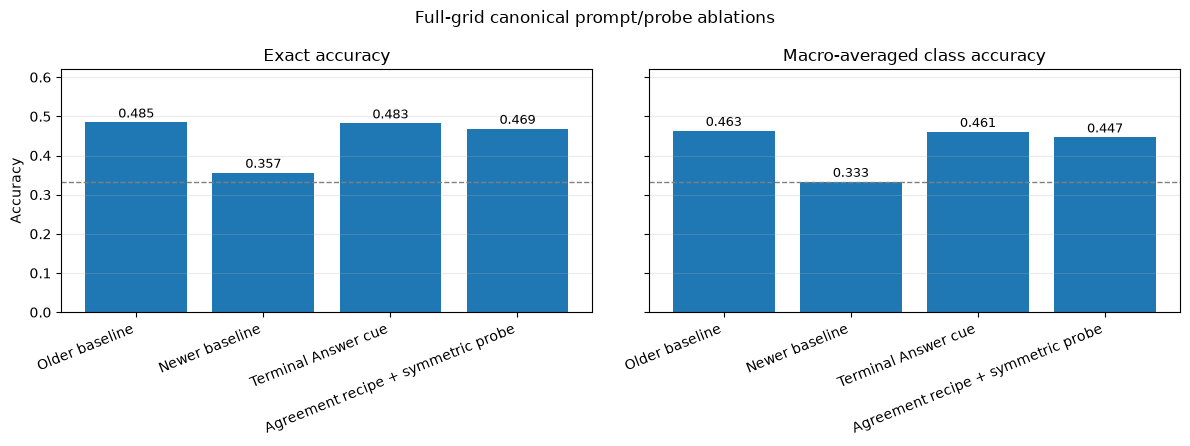


Pilot counterbalanced grid (repeat < 4; all six label assignments)
variant	n	accuracy	balanced_accuracy
baseline_older_cb	448	0.4933	0.4493
baseline_newer_cb	448	0.4754	0.4789
answer_cue_cb	448	0.5223	0.5100
likelihood_symbolic_cue_cb	448	0.5089	0.4827

Pilot two-stage binary readout (repeat < 4; canonical response words)
variant	probe	n	accuracy	balanced_accuracy	pred_left	pred_right	pred_tie
two_stage_newer	candidate	224	0.2500	0.3333	0.0000	1.0000	0.0000
two_stage_newer	half	224	0.3616	0.3333	0.0000	1.0000	0.0000
two_stage_likelihood	candidate	224	0.2500	0.3333	0.0000	1.0000	0.0000
two_stage_likelihood	half	224	0.3616	0.3333	0.0000	1.0000	0.0000

Pilot targeted response-bias warnings (repeat < 4; canonical order)
variant	probe	accuracy	balanced_accuracy	pred_left	pred_right	pred_tie
answer_cue_tie_guard	candidate	0.4375	0.3799	0.2366	0.0000	0.7634
answer_cue_tie_guard	half	0.3705	0.4562	0.3482	0.0000	0.6518
answer_cue_label_guard	candidate	0.3750	0.3509	0.8929	0.0536	0.0536
answer_

In [15]:
ablation_path = ARTIFACT_DIR / "prompt_probe_ablation_results.jsonl"
with ablation_path.open() as handle:
    prompt_ablation_records = [json.loads(line) for line in handle if line.strip()]

full_ablation_records = []
for row in canonical_records:
    full_ablation_records.append(
        {
            **row,
            "variant": f"baseline_{row['prompt_variant']}",
            "choice_mass": row["choice_probability_mass"],
        }
    )
full_ablation_records.extend(
    row for row in prompt_ablation_records
    if row["variant"] in {"newer_answer_cue_full", "likelihood_symbolic_cue_full"}
)

full_variant_order = [
    "baseline_older",
    "baseline_newer",
    "newer_answer_cue_full",
    "likelihood_symbolic_cue_full",
]
full_variant_labels = {
    "baseline_older": "Older baseline",
    "baseline_newer": "Newer baseline",
    "newer_answer_cue_full": "Terminal Answer cue",
    "likelihood_symbolic_cue_full": "Agreement recipe + symmetric probe",
}

summary_by_variant = {}
print("Full canonical grid")
print("variant\tn\taccuracy\tbalanced_accuracy\tchoice_mass\tpred_left\tpred_right\tpred_tie")
for variant in full_variant_order:
    subset = [row for row in full_ablation_records if row["variant"] == variant]
    predicted_rates = {
        semantic: mean_value([row["predicted_semantic_choice"] == semantic for row in subset])
        for semantic in SEMANTIC_CHOICES
    }
    summary_by_variant[variant] = {
        "accuracy": mean_value([float(row["correct"]) for row in subset]),
        "balanced_accuracy": balanced_accuracy_from_records(subset),
        "choice_mass": mean_value([float(row["choice_mass"]) for row in subset]),
    }
    values = summary_by_variant[variant]
    print(
        f"{full_variant_labels[variant]}\t{len(subset)}\t{values['accuracy']:.4f}\t"
        f"{values['balanced_accuracy']:.4f}\t{values['choice_mass']:.4f}\t"
        + "\t".join(f"{predicted_rates[s]:.4f}" for s in SEMANTIC_CHOICES)
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for axis, metric, title in zip(
    axes,
    ("accuracy", "balanced_accuracy"),
    ("Exact accuracy", "Macro-averaged class accuracy"),
):
    values = [summary_by_variant[variant][metric] for variant in full_variant_order]
    bars = axis.bar(range(len(values)), values)
    axis.axhline(1 / 3, color="0.5", linestyle="--", linewidth=1)
    axis.set_xticks(range(len(values)), [full_variant_labels[v] for v in full_variant_order], rotation=22, ha="right")
    axis.set_title(title)
    axis.set_ylim(0, 0.62)
    axis.grid(axis="y", alpha=0.25)
    for bar, value in zip(bars, values):
        axis.text(bar.get_x() + bar.get_width() / 2, value + 0.012, f"{value:.3f}", ha="center", fontsize=9)
axes[0].set_ylabel("Accuracy")
fig.suptitle("Full-grid canonical prompt/probe ablations")
fig.tight_layout()
plt.show()

print("\nPilot counterbalanced grid (repeat < 4; all six label assignments)")
print("variant\tn\taccuracy\tbalanced_accuracy")
pilot_counterbalanced_variants = [
    "baseline_older_cb",
    "baseline_newer_cb",
    "answer_cue_cb",
    "likelihood_symbolic_cue_cb",
]
for variant in pilot_counterbalanced_variants:
    subset = [row for row in prompt_ablation_records if row["variant"] == variant]
    print(
        f"{variant}\t{len(subset)}\t"
        f"{mean_value([float(row['correct']) for row in subset]):.4f}\t"
        f"{balanced_accuracy_from_records(subset):.4f}"
    )

print("\nPilot two-stage binary readout (repeat < 4; canonical response words)")
print("variant\tprobe\tn\taccuracy\tbalanced_accuracy\tpred_left\tpred_right\tpred_tie")
for variant in ("two_stage_newer", "two_stage_likelihood"):
    for probe_kind in ("candidate", "half"):
        subset = [
            row for row in prompt_ablation_records
            if row["variant"] == variant and row["probe_kind"] == probe_kind
        ]
        rates = {
            semantic: mean_value([row["predicted_semantic_choice"] == semantic for row in subset])
            for semantic in SEMANTIC_CHOICES
        }
        print(
            f"{variant}\t{probe_kind}\t{len(subset)}\t"
            f"{mean_value([float(row['correct']) for row in subset]):.4f}\t"
            f"{balanced_accuracy_from_records(subset):.4f}\t"
            + "\t".join(f"{rates[s]:.4f}" for s in SEMANTIC_CHOICES)
        )

print("\nPilot targeted response-bias warnings (repeat < 4; canonical order)")
print("variant\tprobe\taccuracy\tbalanced_accuracy\tpred_left\tpred_right\tpred_tie")
for variant in ("answer_cue_tie_guard", "answer_cue_label_guard", "likelihood_label_guard"):
    for probe_kind in ("candidate", "half"):
        subset = [
            row for row in prompt_ablation_records
            if row["variant"] == variant and row["probe_kind"] == probe_kind
        ]
        rates = {
            semantic: mean_value([row["predicted_semantic_choice"] == semantic for row in subset])
            for semantic in SEMANTIC_CHOICES
        }
        print(
            f"{variant}\t{probe_kind}\t"
            f"{mean_value([float(row['correct']) for row in subset]):.4f}\t"
            f"{balanced_accuracy_from_records(subset):.4f}\t"
            + "\t".join(f"{rates[s]:.4f}" for s in SEMANTIC_CHOICES)
        )

### Layerwise output-token probe

As a lightweight mechanistic localization, this applies Qwen's final RMS norm and unembedding to the residual stream at the final prompt position after every layer. It is an untrained logit lens, so intermediate values should be interpreted qualitatively. The sample contains all 56 repeat-zero decisions per prompt and probe in canonical order.

`C − A` measures the tie-label margin; `To − A` measures pressure to begin an explanatory continuation rather than emit an allowed label. A late divergence supports an answer-readout account more strongly than a story in which the newer rules changed the posterior representation throughout the network.

older candidate final C-A=-0.308 B-A=-3.571 To-A=2.202
older half final C-A=0.180 B-A=-2.621 To-A=1.975


newer candidate final C-A=1.853 B-A=-0.907 To-A=-0.739
newer half final C-A=1.528 B-A=-0.863 To-A=-1.190


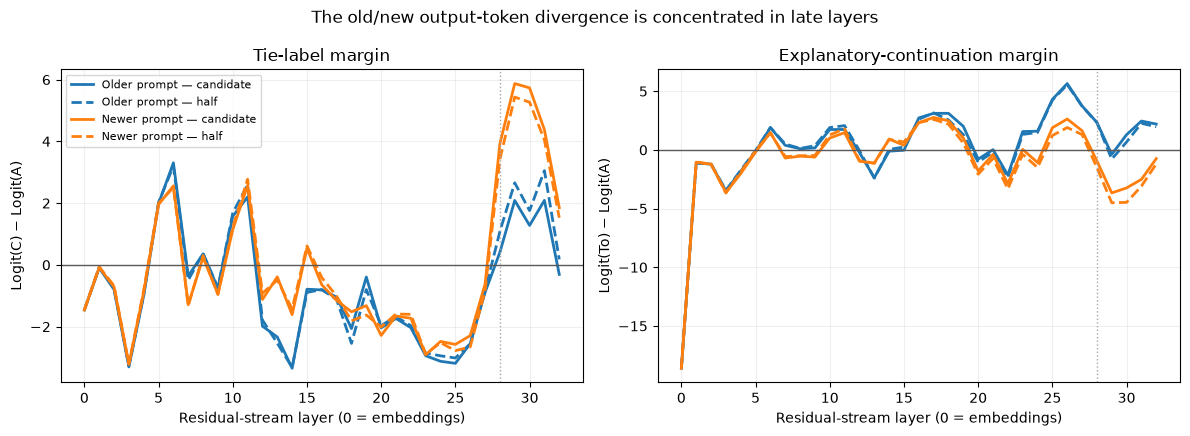

In [16]:
logit_lens_path = ARTIFACT_DIR / "prompt_logit_lens.json"
logit_lens_payload = json.loads(logit_lens_path.read_text())
logit_lens_records = logit_lens_payload["records"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
line_styles = {"candidate": "-", "half": "--"}
colors = {"older": "tab:blue", "newer": "tab:orange"}
for prompt_variant in PROMPT_VARIANTS:
    for probe_kind in ("candidate", "half"):
        subset = sorted(
            (row for row in logit_lens_records if row["prompt_variant"] == prompt_variant and row["probe_kind"] == probe_kind),
            key=lambda row: row["layer"],
        )
        label = f"{PROMPT_VARIANT_LABELS[prompt_variant]} — {probe_kind}"
        axes[0].plot(
            [row["layer"] for row in subset],
            [row["margin_C_minus_A"] for row in subset],
            color=colors[prompt_variant], linestyle=line_styles[probe_kind], linewidth=2, label=label,
        )
        axes[1].plot(
            [row["layer"] for row in subset],
            [row["logit_To"] - row["logit_A"] for row in subset],
            color=colors[prompt_variant], linestyle=line_styles[probe_kind], linewidth=2, label=label,
        )
        final = subset[-1]
        print(
            prompt_variant, probe_kind,
            f"final C-A={final['margin_C_minus_A']:.3f}",
            f"B-A={final['margin_B_minus_A']:.3f}",
            f"To-A={final['logit_To'] - final['logit_A']:.3f}",
        )
for axis, title, ylabel in zip(
    axes,
    ("Tie-label margin", "Explanatory-continuation margin"),
    ("Logit(C) − Logit(A)", "Logit(To) − Logit(A)"),
):
    axis.axhline(0, color="0.35", linewidth=1)
    axis.axvline(28, color="0.65", linestyle=":", linewidth=1)
    axis.set_xlabel("Residual-stream layer (0 = embeddings)")
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.grid(alpha=0.2)
axes[0].legend(fontsize=8)
fig.suptitle("The old/new output-token divergence is concentrated in late layers")
fig.tight_layout()
plt.show()

## Strict raw-evidence single-pass prompt/probe search

The search below preserves the actual task boundary. Qwen sees only the uniform prior, the stated reliability, and the three raw membership-question/report pairs. It is never given target-derived agreement counts, YES-count summaries, posterior values, or a learned readout, and the evaluator performs no Bayesian calculation on Qwen's behalf.

Prompt and probe variants were selected using repeats 0–3 (development) and 8–11 (validation). Repeats 12–15 were evaluated once after freezing the method. The strongest single-pass method keeps the newer rules and terminal `Answer:` cue, then averages next-token semantic log probabilities across task-preserving presentations:

- Candidate probes: all eight cyclic renamings of values 1–8 crossed with three cyclic A/B/C assignments (24 presentations).
- Half-domain probes: three cyclic observation orders crossed with the same three A/B/C assignments (9 presentations).

Renaming values and reordering independent observations preserve the posterior comparison. These are inference-time symmetry probes, not additional evidence. Their larger inference budget must be kept in mind when comparing them with the six-label baseline.

In [17]:
honest_results_path = ARTIFACT_DIR / "honest_symmetry_results.jsonl"
honest_manifest_path = ARTIFACT_DIR / "honest_symmetry_manifest.json"

with honest_results_path.open() as handle:
    honest_symmetry_records = [json.loads(line) for line in handle if line.strip()]
honest_symmetry_manifest = json.loads(honest_manifest_path.read_text())

expected_per_split = 4 * 8 * len(reliability_values) * 2
for split_name in ("development", "validation", "test"):
    split_rows = [row for row in honest_symmetry_records if row["split"] == split_name]
    if len(split_rows) != expected_per_split:
        raise RuntimeError(
            f"Incomplete {split_name} symmetry results: "
            f"expected {expected_per_split}, found {len(split_rows)}"
        )

print("split\tprobe\tn\taccuracy\tbalanced_accuracy\tpred_left\tpred_right\tpred_tie")
for split_name in ("development", "validation", "test"):
    for probe_kind in ("candidate", "half", "pooled"):
        subset = [
            row for row in honest_symmetry_records
            if row["split"] == split_name
            and (probe_kind == "pooled" or row["probe_kind"] == probe_kind)
        ]
        prediction_rates = {
            semantic: mean_value([
                row["predicted_semantic_choice"] == semantic for row in subset
            ])
            for semantic in SEMANTIC_CHOICES
        }
        print(
            f"{split_name}\t{probe_kind}\t{len(subset)}\t"
            f"{mean_value([float(row['correct']) for row in subset]):.4f}\t"
            f"{balanced_accuracy_from_records(subset):.4f}\t"
            + "\t".join(f"{prediction_rates[s]:.4f}" for s in SEMANTIC_CHOICES)
        )

split	probe	n	accuracy	balanced_accuracy	pred_left	pred_right	pred_tie
development	candidate	224	0.6250	0.5549	0.5312	0.0000	0.4688
development	half	224	0.5491	0.5699	0.7188	0.0000	0.2812
development	pooled	448	0.5871	0.5640	0.6250	0.0000	0.3750
validation	candidate	224	0.5536	0.4639	0.4464	0.0000	0.5536
validation	half	224	0.4911	0.4929	0.7143	0.0000	0.2857
validation	pooled	448	0.5223	0.4892	0.5804	0.0000	0.4196
test	candidate	224	0.5938	0.6009	0.5179	0.0000	0.4821
test	half	224	0.4911	0.5327	0.7143	0.0000	0.2857
test	pooled	448	0.5424	0.5733	0.6161	0.0000	0.3839


### Targeted wording ablation

The phrase “their selection provides no additional information” is formally correct but easy to scope incorrectly: a small model may blur “the selected sets are non-informative” into “the reports are non-informative.” The newer prompt also repeats `exactly`/`equals` shortly before an “equal posterior” answer. Two raw-evidence-only rewrites were therefore screened:

**Clarified selection**

> A secret s was drawn uniformly from the set {1, ..., N}. For each displayed set Q, the correct answer is YES exactly when s is in Q. The observed report equals that correct answer with probability r, and equals the opposite answer with probability 1-r. Reports are independent conditional on s. An outside process fixed the three displayed sets independently of s. The observed YES/NO reports are evidence about s. Use all three observed reports and the stated value of r to compare the requested posterior probabilities.

**Minimal channel**

> A secret s was sampled uniformly from the integers 1 through N. Each question displays a set Q and asks whether s is in Q. Its YES/NO report matches the true membership answer with probability r and is flipped with probability 1-r. The three reports are conditionally independent given s. An outside process fixed all three displayed sets independently of s. Treat the displayed reports as evidence and compare the requested posterior probabilities.

The clarified version reached 57.6% pooled on development and changed the left/tie mixture, but its half-set accuracy fell to 45.5% on validation versus 49.1% for the selected probe. The minimal version reached 55.6% on development. Neither predicted `right`, so both were rejected before final testing.

In [18]:
rewrite_ablation_path = ARTIFACT_DIR / "honest_prompt_rewrite_ablation_results.jsonl"
rewrite_manifest_path = ARTIFACT_DIR / "honest_prompt_rewrite_ablation_manifest.json"

with rewrite_ablation_path.open() as handle:
    rewrite_ablation_records = [json.loads(line) for line in handle if line.strip()]
rewrite_ablation_manifest = json.loads(rewrite_manifest_path.read_text())

print("split\tprompt_rewrite\tprobe\tn\taccuracy\tpred_left\tpred_right\tpred_tie")
groups = sorted({
    (row["split"], row["prompt_rewrite"], row["probe_kind"])
    for row in rewrite_ablation_records
})
for split_name, prompt_rewrite, probe_kind in groups:
    subset = [
        row for row in rewrite_ablation_records
        if row["split"] == split_name
        and row["prompt_rewrite"] == prompt_rewrite
        and row["probe_kind"] == probe_kind
    ]
    rates = {
        semantic: mean_value([
            row["predicted_semantic_choice"] == semantic for row in subset
        ])
        for semantic in SEMANTIC_CHOICES
    }
    print(
        f"{split_name}\t{prompt_rewrite}\t{probe_kind}\t{len(subset)}\t"
        f"{mean_value([float(row['correct']) for row in subset]):.4f}\t"
        + "\t".join(f"{rates[s]:.4f}" for s in SEMANTIC_CHOICES)
    )

split	prompt_rewrite	probe	n	accuracy	pred_left	pred_right	pred_tie
development	clarified_selection	candidate	224	0.5982	0.6652	0.0000	0.3348
development	clarified_selection	half	224	0.5536	0.7009	0.0000	0.2991
development	minimal_channel	candidate	224	0.5670	0.7054	0.0000	0.2946
development	minimal_channel	half	224	0.5446	0.6875	0.0000	0.3125
validation_half_only	clarified_selection	half	224	0.4554	0.6295	0.0000	0.3705


### Mechanistic interpretation

The interventions point to a late answer-readout failure rather than successful posterior computation with a small calibration error.

1. Turning option counterbalancing off exposes the surface prior directly: the older wording predominantly selects the first/left option, while the newer wording shifts probability toward the equality/tie option.
2. Permuting A/B/C reduces literal token bias but does not restore antisymmetry: even the strongest single-pass symmetry probe never predicts semantic `right` on the held-out test set.
3. Reversing the two operands is not equivariant. In development, the selected direction scored 65.2% on the initial two-repeat slice, the reversed direction scored 44.6%, and geometrically combining both fell to 36.6%.
4. Cyclically renaming the eight values improves candidate accuracy, so arbitrary numerical identities are part of the nuisance signal. It still does not recover `right`, showing that number bias is only one component.
5. The untrained layerwise output-token probe above localizes much of the old/new divergence to late layers. Together with the failed algorithm/checklist and free-form-reasoning variants, this supports a response-prior/readout bottleneck: the new wording makes “equal” a salient completion, while the older wording leaves the first listed quantity as the safest completion.

The single-pass symmetry probe improves held-out accuracy by distinguishing left from tie more reliably; it does **not** demonstrate that Qwen learned the likelihood calculation.

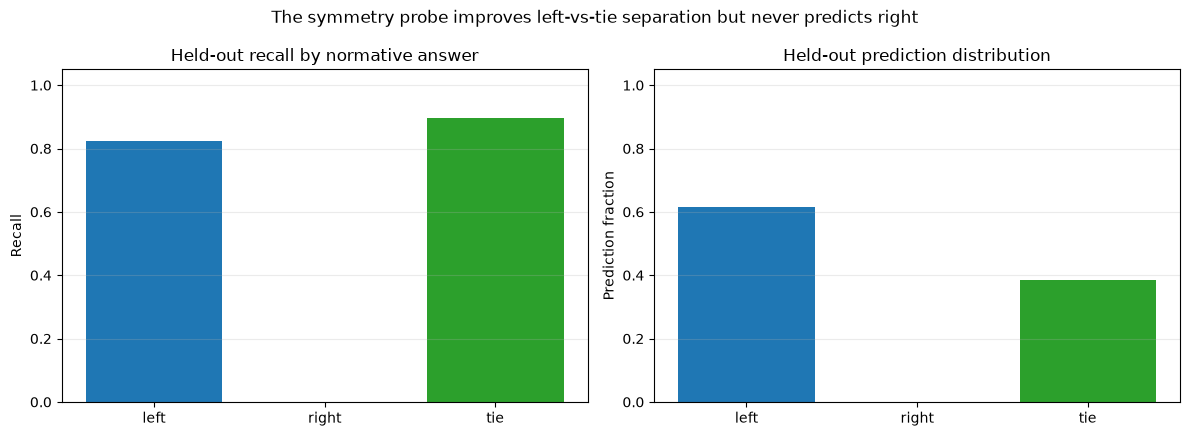

In [19]:
test_symmetry_rows = [
    row for row in honest_symmetry_records if row["split"] == "test"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

semantic_recalls = []
for semantic in SEMANTIC_CHOICES:
    class_rows = [
        row for row in test_symmetry_rows
        if row["normative_semantic_choice"] == semantic
    ]
    semantic_recalls.append(mean_value([float(row["correct"]) for row in class_rows]))
axes[0].bar(SEMANTIC_CHOICES, semantic_recalls, color=["tab:blue", "tab:orange", "tab:green"])
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Recall")
axes[0].set_title("Held-out recall by normative answer")
axes[0].grid(axis="y", alpha=0.25)

prediction_rates = [
    mean_value([row["predicted_semantic_choice"] == semantic for row in test_symmetry_rows])
    for semantic in SEMANTIC_CHOICES
]
axes[1].bar(SEMANTIC_CHOICES, prediction_rates, color=["tab:blue", "tab:orange", "tab:green"])
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Prediction fraction")
axes[1].set_title("Held-out prediction distribution")
axes[1].grid(axis="y", alpha=0.25)

fig.suptitle("The symmetry probe improves left-vs-tie separation but never predicts right")
fig.tight_layout()
plt.show()

## Selected candidate probe: one call, no thinking

The selected prompt keeps the original $N=8$, $K=3$ random-memoryless game.  A
single Qwen3.5-4B continuation sees only the public game rules, reliability, three
raw membership questions/reports, and the two candidate identities.  There are no
intermediate model calls, thinking mode is disabled, and evaluator-derived
memberships, agreement counts, likelihoods, posteriors, channel coins, and target
labels are never included in the model messages.

Two simple changes fix the earlier directional readout collapse: the prompt asks
for the winning candidate's integer rather than a positional A/B or FIRST/SECOND
label, and a generic system message asks Qwen to apply the stated Bayesian game
rules carefully.  Qwen may write a concise derivation in its one visible response.
Presentation order is selected by SHA-256 of the public example ID, independent of
the target.

The prompt was developed on repeat 0 (52/56, 92.9%), frozen before repeat 1
(47/56, 83.9%), and then scored without changes on held-out repeats 2–3 (107/112,
95.5%).  All 224 responses parsed.  Reproduce the held-out run with:

```bash
uv run --frozen python scripts/run_single_call_candidate.py \
  --output artifacts/single_call_candidate/test_system_reason_results.jsonl \
  --manifest artifacts/single_call_candidate/test_system_reason_manifest.json \
  --repeats 2,3 --variant number_system_reason --batch-size 4 --overwrite
```

At exactly $r=0.5$, every secret has the same likelihood for every report history,
so every candidate pair is normatively tied.  Three-way argmax accuracy can
therefore be 100% at maximal channel entropy; it is not an information-sensitive
measure at that point.


In [20]:
single_call_dir = REPO_ROOT / "artifacts" / "single_call_candidate"
single_call_manifest_paths = {
    "development": single_call_dir / "development_system_reason_manifest.json",
    "validation": single_call_dir / "validation_system_reason_manifest.json",
    "test": single_call_dir / "test_system_reason_manifest.json",
}
single_call_expected = {
    "development": (56, 52),
    "validation": (56, 47),
    "test": (112, 107),
}

for split_name, manifest_path in single_call_manifest_paths.items():
    manifest = json.loads(manifest_path.read_text())
    summary = manifest["summary"]
    expected_n, expected_correct = single_call_expected[split_name]
    assert manifest["scope"] == "candidate-only, exactly one Qwen continuation per transcript"
    assert manifest["game"] == {"n": 8, "k": 3, "policy": "random_memoryless"}
    assert manifest["variant"]["enable_thinking"] is False
    assert summary["records"] == expected_n
    assert round(summary["accuracy"] * expected_n) == expected_correct
    assert summary["parse_rate"] == 1.0
    print(
        split_name,
        f"n={summary['records']}",
        f"accuracy={summary['accuracy']:.4f}",
        f"parse={summary['parse_rate']:.4f}",
        f"predictions={summary['prediction_counts']}",
    )


development n=56 accuracy=0.9286 parse=1.0000 predictions={'2': 22, '7': 11, 'tie': 23}
validation n=56 accuracy=0.8393 parse=1.0000 predictions={'2': 21, '7': 13, 'tie': 22}
test n=112 accuracy=0.9554 parse=1.0000 predictions={'2': 33, '7': 28, 'tie': 51}
